In [20]:
import warnings

# 忽略所有 FutureWarning (未来版本警告)
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载纯金数据
df = pd.read_csv("cs2_pro_2026_Active_Master.csv")

# 2. 配置暗黑电竞风皮肤
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "#E0E0E0", "axes.labelcolor": "#E0E0E0", "xtick.color": "#A0A0A0", "ytick.color": "#A0A0A0", "grid.color": "#2A2A2A"})

print(f"✅ 成功连接至分析池，目标人数: {len(df)}")

✅ 成功连接至分析池，目标人数: 189


In [4]:
# ==========================================
# 🛡️ Data Quality Control (质检闸门)
# ==========================================
import pandas as pd

# 1. 加载我们之前的 Master 总表
df = pd.read_csv("cs2_pro_2026_Active_Master.csv")
original_len = len(df)

# 2. 核心质检 1：剔除缺失关键数据的“空壳选手”
# 如果一个选手连最基本的 eDPI 和 Resolution (分辨率) 都没有，那他没有任何分析价值
df_clean = df.dropna(subset=['eDPI', 'Resolution']).copy()

# 3. 核心质检 2：剔除“假人” (选手名和队伍名一样的情况，比如叫 fnatic 的选手)
df_clean = df_clean[df_clean['Player'].str.lower() != df_clean['Team'].str.lower()]

# 4. 核心质检 3：大小写去重 (解决 levi 和 Levi 的双胞胎问题)
# 创建一个临时的小写名字列，按这个列去重，保留第一条数据
df_clean['Player_lower'] = df_clean['Player'].str.lower()
df_clean = df_clean.drop_duplicates(subset=['Player_lower'], keep='first')
# 删掉临时的辅助列
df_clean = df_clean.drop(columns=['Player_lower'])

print("🛡️ 数据质检完毕！")
print(f"📉 原始数据行数: {original_len}")
print(f"📈 质检后纯度 100% 的有效人数: {len(df_clean)}")
print(f"🗑️ 共拦截并清除了 {original_len - len(df_clean)} 条残次品/重复数据！")

# 以后我们就用 df_clean 进行分析了！你可以覆盖保存一下，方便以后用
df_clean.to_csv("cs2_pro_2026_Active_Cleaned.csv", index=False, encoding='utf-8-sig')

🛡️ 数据质检完毕！
📉 原始数据行数: 189
📈 质检后纯度 100% 的有效人数: 184
🗑️ 共拦截并清除了 5 条残次品/重复数据！


In [5]:
# ==========================================
# 🎨 Phase 3: EDA & 电竞暗黑风环境初始化
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 设置 Matplotlib 暗黑主题
plt.style.use('dark_background')

# 2. 深度定制 Seaborn 参数，打造 CS2 赛博电竞风
sns.set_context("notebook", font_scale=1.1)
sns.set_palette(["#00FF00", "#FF4500", "#00E5FF", "#FF00FF", "#FFFF00"]) # 荧光绿, 亮橙(CS2主色调), 冰蓝, 霓虹粉, 亮黄
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = '#121212'       # 图表背景色: 极暗灰
plt.rcParams['figure.facecolor'] = '#0a0a0a'     # 画布背景色: 纯黑边缘
plt.rcParams['grid.color'] = '#333333'           # 网格线颜色
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.edgecolor'] = '#555555'       # 边框颜色

# 3. 加载我们的终极 Master 纯净表
df_pro = pd.read_csv("cs2_pro_2026_Active_Cleaned.csv")

print("🎮 电竞暗黑数据画板初始化成功！")
print(f"✅ 成功加载 {len(df_pro)} 名现役顶级选手的硬核参数。")
print("🚀 准备开始可视化输出...")

🎮 电竞暗黑数据画板初始化成功！
✅ 成功加载 184 名现役顶级选手的硬核参数。
🚀 准备开始可视化输出...


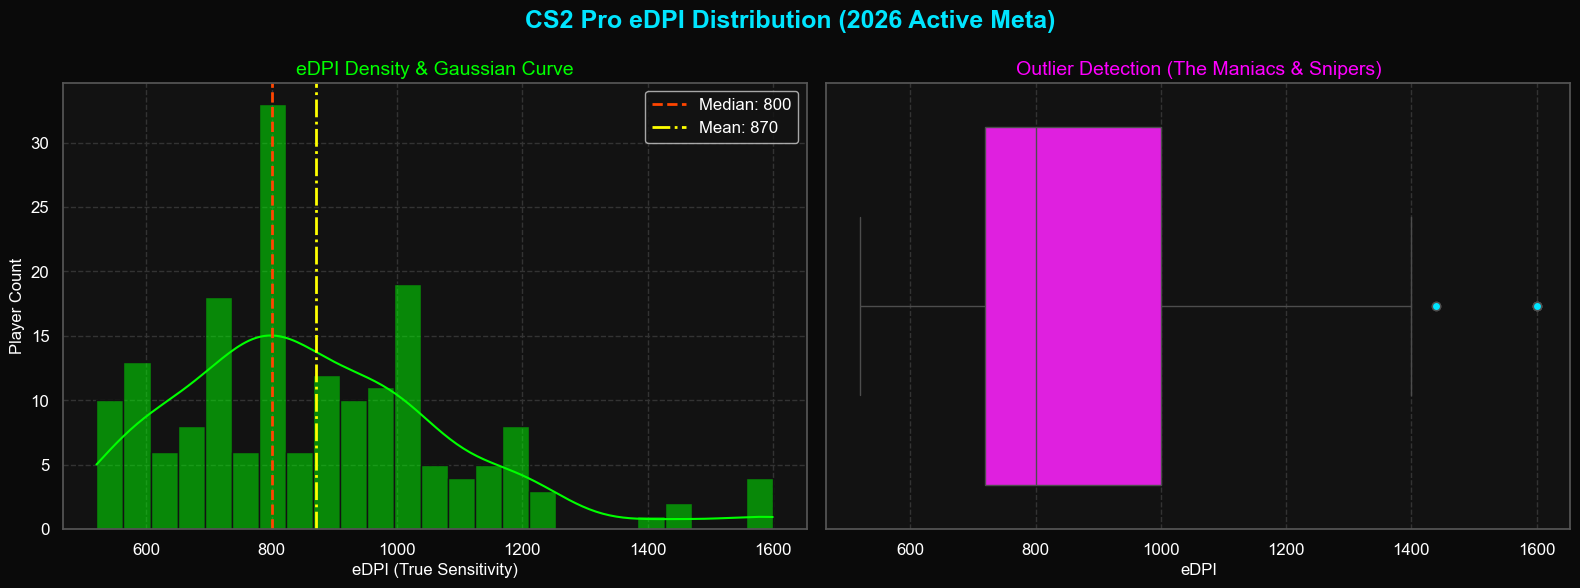

🔥[极高 eDPI 疯狗流玩家]:
       Player         Team    eDPI
26      woxic       Aurora  1600.0
81    piriajr  paiN Gaming  1600.0
147     chelo     Imperial  1600.0
181    Xant3r          TDK  1600.0
27    Wicadia       Aurora  1440.0
71    saadzin       Legacy  1440.0
133      nicx   Passion UA  1400.0
60   HeavyGod   G2 Esports  1240.0
124    s1mple      BC.Game  1236.0
141      kl1m         MIBR  1236.0

🧊 [极低 eDPI 稳健流玩家]:
       Player        Team   eDPI
94   kensizor          B8  520.0
127  aragornN     BC.Game  540.0
157      fear      fnatic  540.0
177   maxster  EYEBALLERS  544.0


In [6]:
# ==========================================
# 🎯 Cell 3: eDPI 宏观分布分析 (控枪流派的真理)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 创建 1行2列 的画布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CS2 Pro eDPI Distribution (2026 Active Meta)', fontsize=18, fontweight='bold', color='#00E5FF')

# --- 图 1：eDPI 分布直方图 + KDE 曲线 (左) ---
sns.histplot(df_pro['eDPI'], bins=25, kde=True, color='#00FF00', edgecolor='#121212', ax=axes[0])
axes[0].set_title('eDPI Density & Gaussian Curve', fontsize=14, color='#00FF00')
axes[0].set_xlabel('eDPI (True Sensitivity)', fontsize=12)
axes[0].set_ylabel('Player Count', fontsize=12)

# 画出 eDPI 的中位数和平均值辅助线
median_edpi = df_pro['eDPI'].median()
mean_edpi = df_pro['eDPI'].mean()
axes[0].axvline(median_edpi, color='#FF4500', linestyle='--', linewidth=2, label=f'Median: {median_edpi:.0f}')
axes[0].axvline(mean_edpi, color='#FFFF00', linestyle='-.', linewidth=2, label=f'Mean: {mean_edpi:.0f}')
axes[0].legend()

# --- 图 2：eDPI 极端值箱线图 (右) ---
sns.boxplot(x=df_pro['eDPI'], color='#FF00FF', ax=axes[1], fliersize=6, flierprops={'markerfacecolor':'#00E5FF'})
axes[1].set_title('Outlier Detection (The Maniacs & Snipers)', fontsize=14, color='#FF00FF')
axes[1].set_xlabel('eDPI', fontsize=12)

plt.tight_layout()
plt.show()

# 顺便打印一下具体的极值哥们是哪几位：
print("🔥[极高 eDPI 疯狗流玩家]:")
print(df_pro[df_pro['eDPI'] > 1200][['Player', 'Team', 'eDPI']].sort_values(by='eDPI', ascending=False))
print("\n🧊 [极低 eDPI 稳健流玩家]:")
print(df_pro[df_pro['eDPI'] < 550][['Player', 'Team', 'eDPI']].sort_values(by='eDPI'))

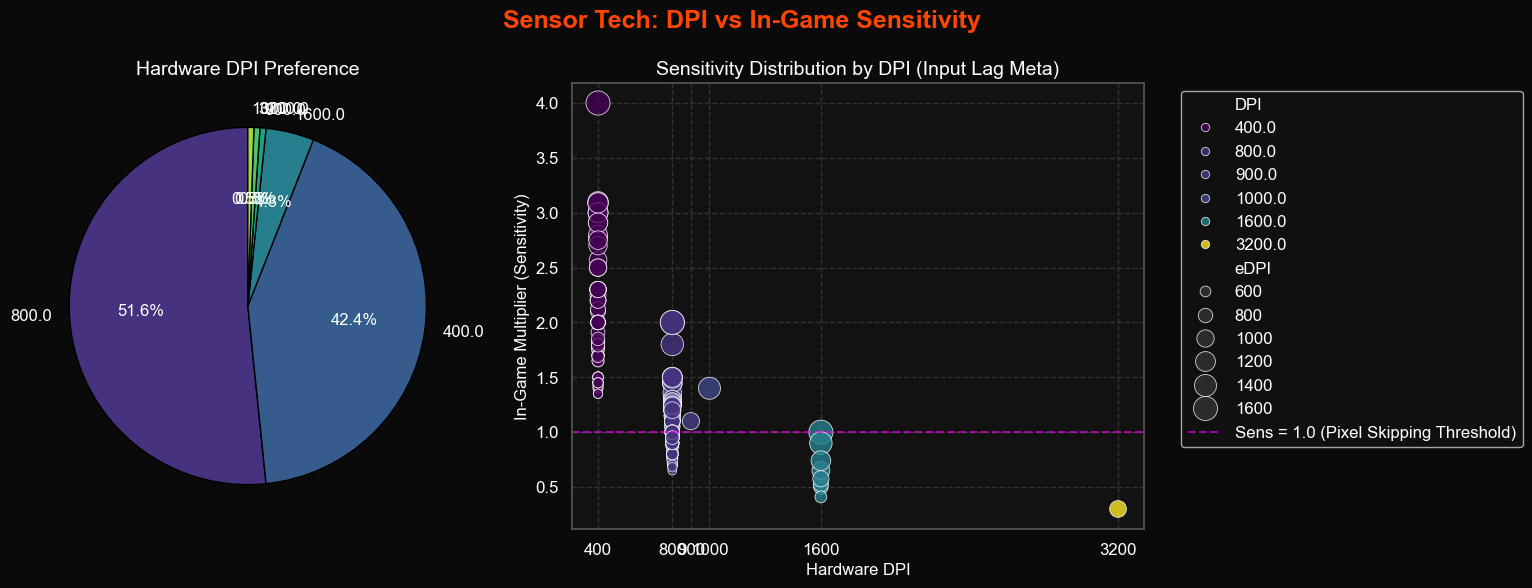

🚀 拥抱高 DPI (>=1600) 以降低输入延迟的先锋选手共 9 人，占比 4.9%


In [7]:
# ==========================================
# ⚙️ Cell 4: DPI vs Sensitivity (输入延迟降维打击分析)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sensor Tech: DPI vs In-Game Sensitivity', fontsize=18, fontweight='bold', color='#FF4500')

# --- 图 1：DPI 的市场占有率饼图 (左) ---
dpi_counts = df_pro['DPI'].value_counts()
axes[0].pie(dpi_counts, labels=dpi_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette("viridis", len(dpi_counts)), 
            startangle=90, textprops={'color':"w", 'fontsize': 12}, wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Hardware DPI Preference', fontsize=14)

# --- 图 2：DPI 与 Sens 组合散点图 (右) ---
# 横轴 DPI，纵轴 Sens，hue用来按DPI上色
sns.scatterplot(data=df_pro, x='DPI', y='Sensitivity', hue='DPI', palette='viridis', 
                size='eDPI', sizes=(40, 300), alpha=0.8, edgecolor='w', ax=axes[1])

# 画一条 Y=1.0 的死线 (Sens < 1.0 通常意味着 800 或 1600 高DPI玩家)
axes[1].axhline(1.0, color='#FF00FF', linestyle='--', alpha=0.6, label='Sens = 1.0 (Pixel Skipping Threshold)')
axes[1].set_title('Sensitivity Distribution by DPI (Input Lag Meta)', fontsize=14)
axes[1].set_xlabel('Hardware DPI', fontsize=12)
axes[1].set_ylabel('In-Game Multiplier (Sensitivity)', fontsize=12)
axes[1].set_xticks(sorted(df_pro['DPI'].unique())) # 强制横坐标只显示存在的DPI数值
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 打印一下步入 1600 DPI 时代的“前卫选手”比例
high_dpi_players = df_pro[df_pro['DPI'] >= 1600]
print(f"🚀 拥抱高 DPI (>=1600) 以降低输入延迟的先锋选手共 {len(high_dpi_players)} 人，占比 {(len(high_dpi_players)/len(df_pro))*100:.1f}%")

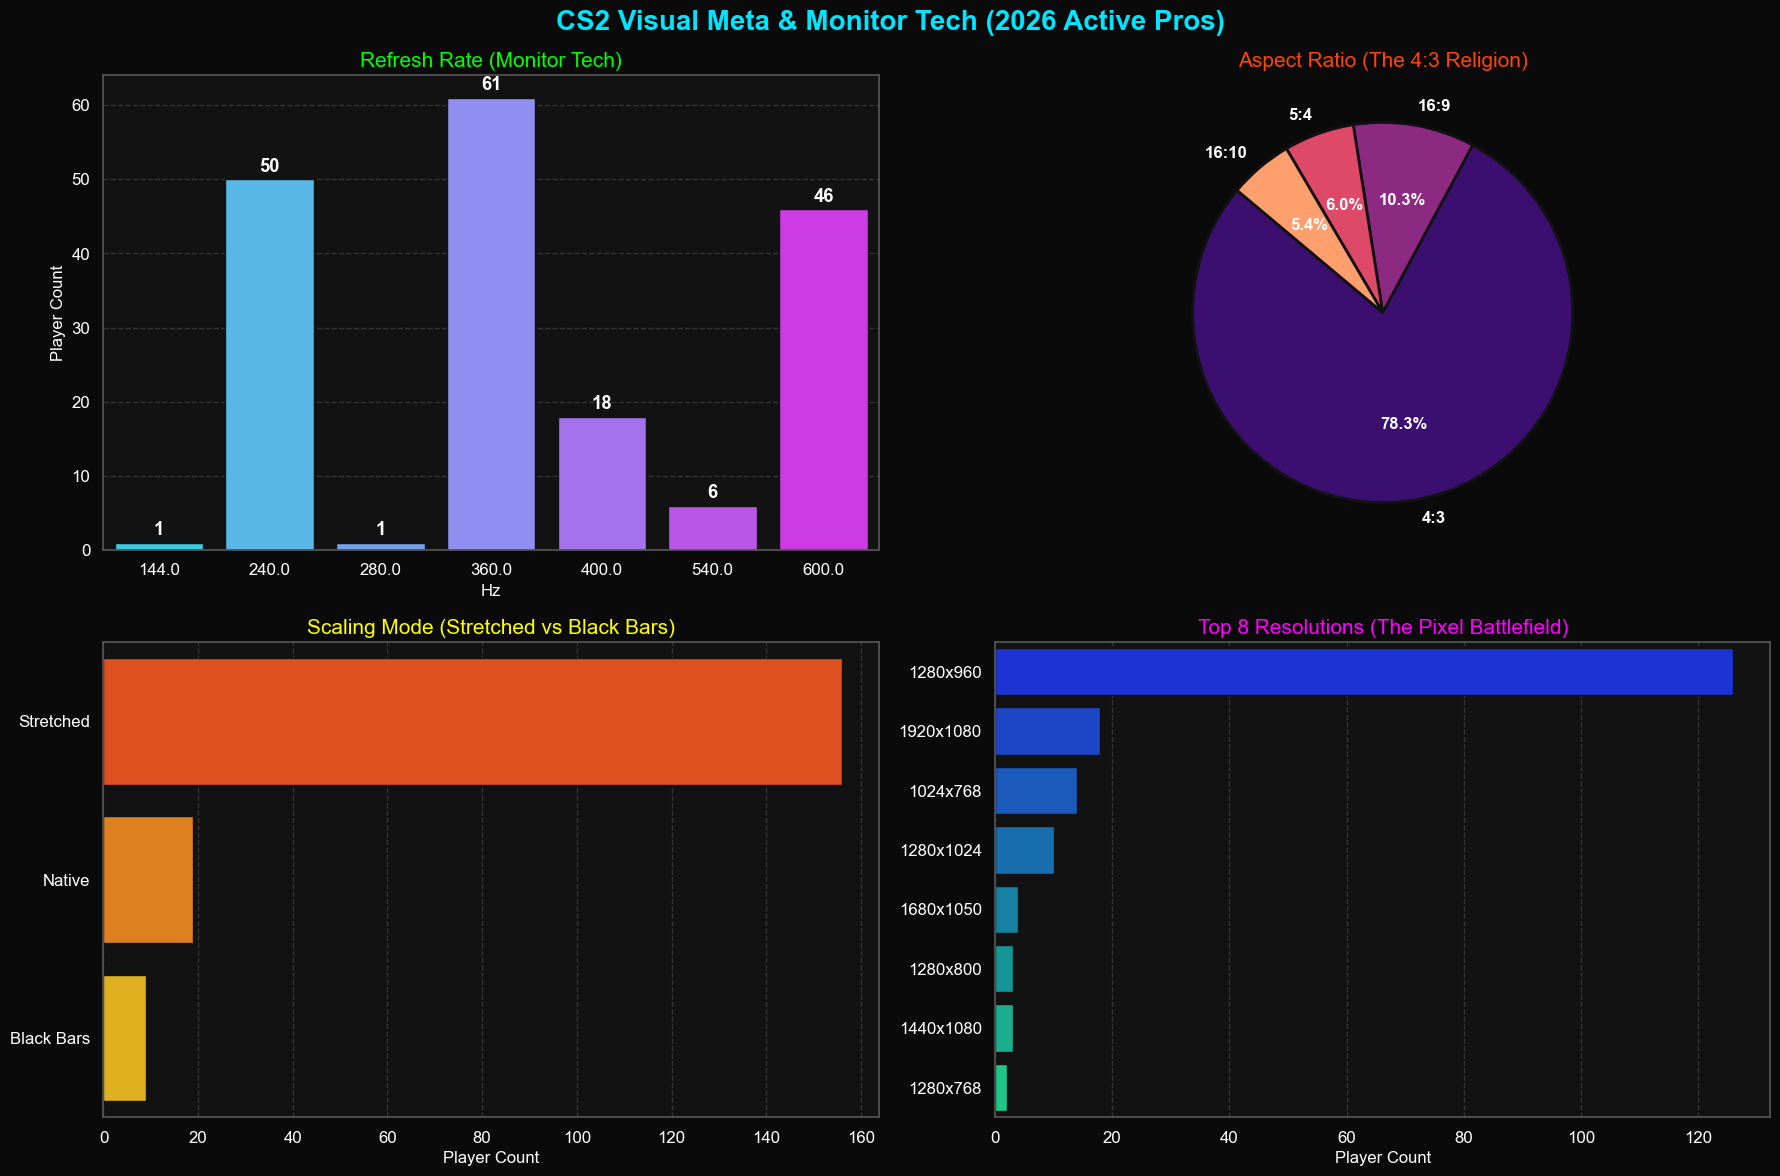

👁️ 拥抱 1440x1080 (原生高清拉伸) 的选手人数: 3 人，占比 1.6%


In [21]:
# ==========================================
# 🖥️ Cell 5: 显示器硬件与视觉 Meta (分辨率、拉伸与刷新率)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('CS2 Visual Meta & Monitor Tech (2026 Active Pros)', fontsize=20, fontweight='bold', color='#00E5FF')

# --- 1. 刷新率生态圈 (Top Left) ---
# 清理 Refresh Rate 字段 (比如把 "360 Hz" 提取成数字)
df_pro['Hz_clean'] = df_pro['Refresh Rate'].astype(str).str.extract(r'(\d+)').astype(float)
hz_counts = df_pro['Hz_clean'].value_counts().sort_index()

sns.barplot(x=hz_counts.index, y=hz_counts.values, palette='cool', ax=axes[0, 0], edgecolor='#121212')
axes[0, 0].set_title('Refresh Rate (Monitor Tech)', fontsize=15, color='#00FF00')
axes[0, 0].set_xlabel('Hz', fontsize=12)
axes[0, 0].set_ylabel('Player Count', fontsize=12)
for i, v in enumerate(hz_counts.values):
    axes[0, 0].text(i, v + 1, str(v), ha='center', color='white', fontweight='bold')

# --- 2. 宽高比选择 (Top Right) ---
ar_counts = df_pro['Aspect Ratio'].value_counts()
axes[0, 1].pie(ar_counts, labels=ar_counts.index, autopct='%1.1f%%', 
               colors=sns.color_palette("magma", len(ar_counts)), 
               startangle=140, wedgeprops={'edgecolor': '#121212', 'linewidth': 2}, 
               textprops={'color':"w", 'fontsize': 12, 'fontweight': 'bold'})
axes[0, 1].set_title('Aspect Ratio (The 4:3 Religion)', fontsize=15, color='#FF4500')

# --- 3. 画面拉伸模式 (Bottom Left) ---
scaling_counts = df_pro['Scaling Mode'].value_counts()
sns.countplot(data=df_pro, y='Scaling Mode', order=scaling_counts.index, palette='autumn', ax=axes[1, 0], edgecolor='#121212')
axes[1, 0].set_title('Scaling Mode (Stretched vs Black Bars)', fontsize=15, color='#FFFF00')
axes[1, 0].set_xlabel('Player Count', fontsize=12)
axes[1, 0].set_ylabel('')

# --- 4. 终极分辨率 Top 8 排行榜 (Bottom Right) ---
res_counts = df_pro['Resolution'].value_counts().head(8)
sns.barplot(x=res_counts.values, y=res_counts.index, palette='winter', ax=axes[1, 1], edgecolor='#121212')
axes[1, 1].set_title('Top 8 Resolutions (The Pixel Battlefield)', fontsize=15, color='#FF00FF')
axes[1, 1].set_xlabel('Player Count', fontsize=12)
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

# 顺便统计一下到底有多少人拥抱了 1440x1080 (高清拉伸)
res_1440 = len(df_pro[df_pro['Resolution'].str.contains('1440x1080', na=False)])
print(f"👁️ 拥抱 1440x1080 (原生高清拉伸) 的选手人数: {res_1440} 人，占比 {(res_1440/len(df_pro))*100:.1f}%")

In [11]:
# ==========================================
# 🩹 Cell 5.5: 数据补丁 - 捞取并持久化增强版数据集
# ==========================================
import pandas as pd

# 1. 读取基础清洗表和极其庞大的 RAW 表
df_clean = pd.read_csv("cs2_pro_2026_Active_Cleaned.csv")
df_raw = pd.read_csv("cs2_pro_detailed_RAW.csv", low_memory=False) 

# 2. 我们需要捞回的“硬核画面特征”
target_columns =[
    'Player', 'Brightness', 'Display Mode', 'V-Sync', 'NVIDIA Reflex Low Latency', 
    'NVIDIA G-Sync', 'Maximum FPS In Game', 'Model / Texture Detail', 
    'Shader Detail', 'Particle Detail', 'Ambient Occlusion', 'High Dynamic Range'
]

# 3. 提取特征并去重缝合
df_features_to_add = df_raw[target_columns].drop_duplicates(subset=['Player'])
df_pro = pd.merge(df_clean, df_features_to_add, on='Player', how='left', suffixes=('', '_new'))

# 4. 覆盖字段并清理冗余列
for col in target_columns:
    if col != 'Player':
        if col + '_new' in df_pro.columns:
            df_pro[col] = df_pro[col + '_new']
            df_pro = df_pro.drop(columns=[col + '_new'])

# 5. 填补一下空值，把 NaN 变成 "Unknown" 方便画图
fill_cols =['Display Mode', 'V-Sync', 'NVIDIA Reflex Low Latency', 'NVIDIA G-Sync', 
             'Model / Texture Detail', 'Shader Detail', 'Particle Detail', 'Ambient Occlusion']
df_pro[fill_cols] = df_pro[fill_cols].fillna('Unknown')

# 6. 【关键操作】数据落盘，保存增强版 Master 表！
save_name = "cs2_pro_2026_Active_Enhanced.csv"
df_pro.to_csv(save_name, index=False, encoding='utf-8-sig')

print("💾 数据补丁打入完毕，并成功落盘！")
print(f"✅ 终极分析表已保存为: {save_name}，后续可以直接用它做 AI 聚类！")

💾 数据补丁打入完毕，并成功落盘！
✅ 终极分析表已保存为: cs2_pro_2026_Active_Enhanced.csv，后续可以直接用它做 AI 聚类！


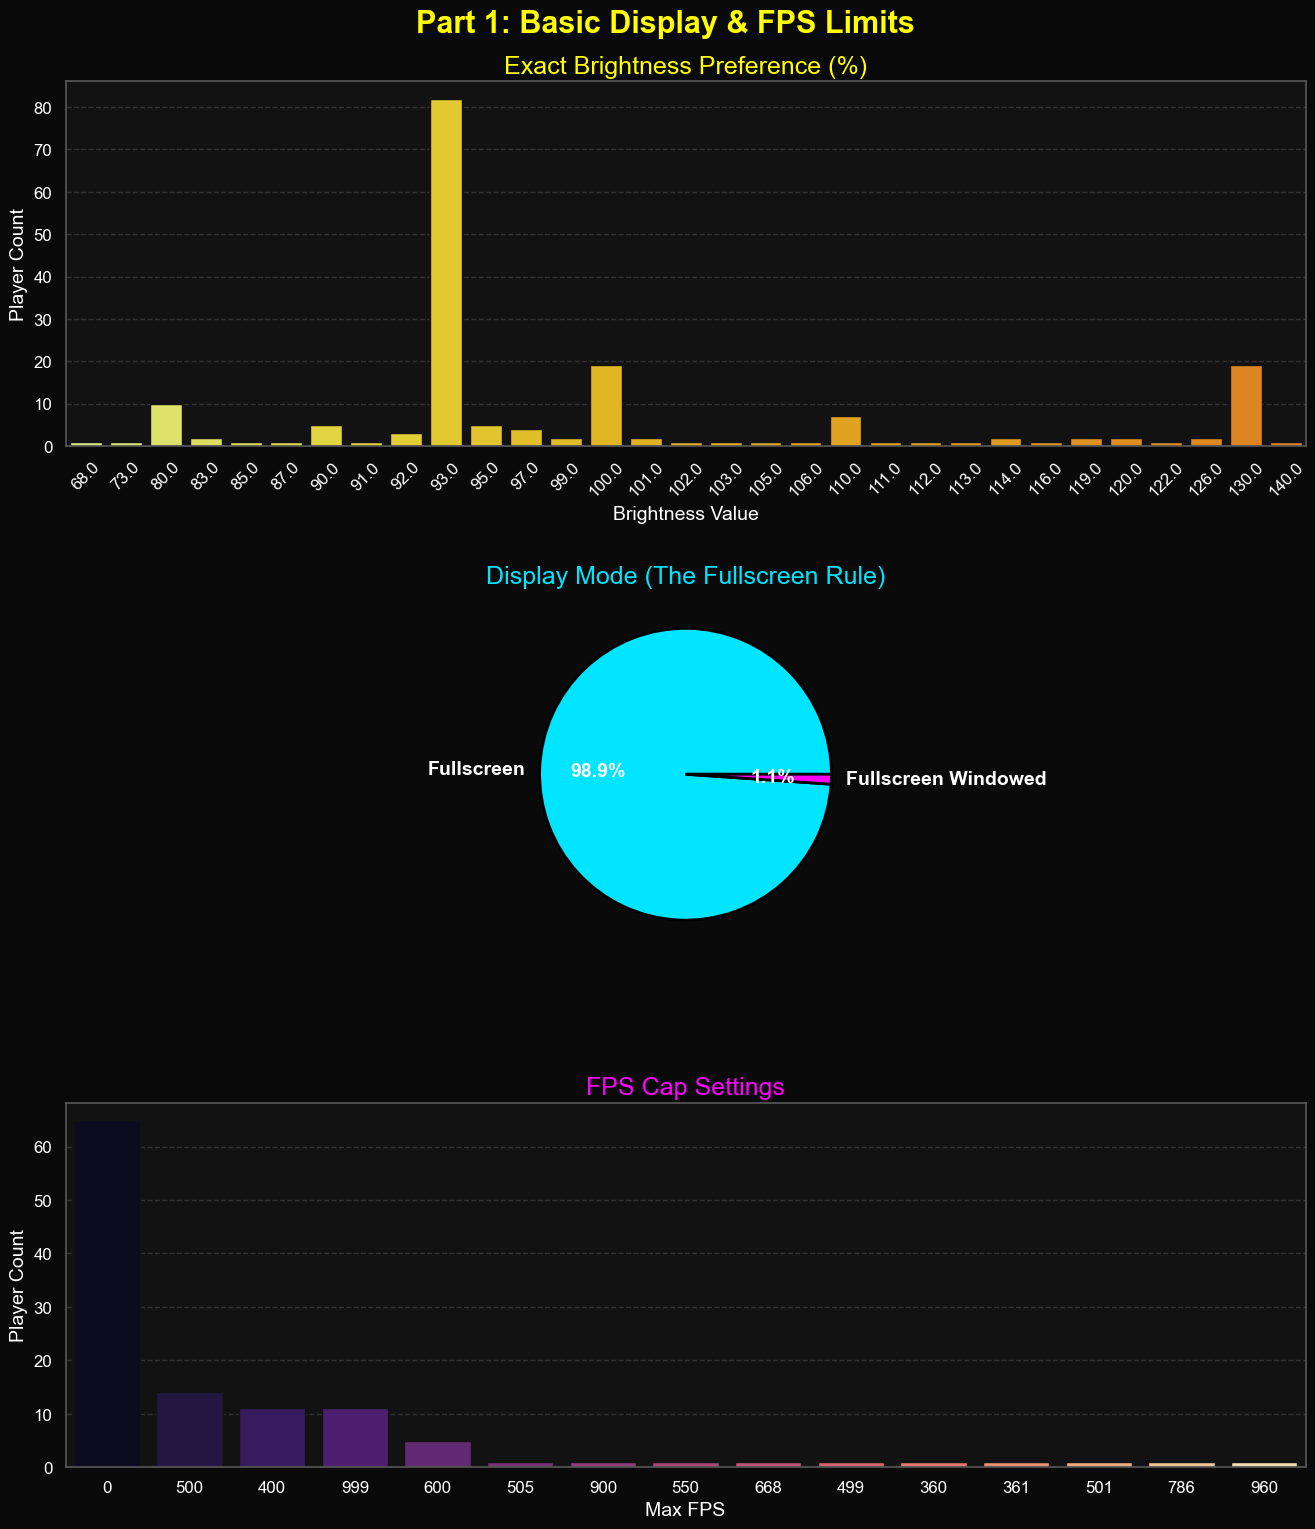

In [22]:
# ==========================================
# ⚙️ Cell 6.1 (重制版): 基础显示与亮度 (The Visual Baseline)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 改为 3行1列 瀑布流排版，画幅增大到 16x18
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Part 1: Basic Display & FPS Limits', fontsize=22, fontweight='bold', color='#FFFF00', y=0.92)

# --- 1. 亮度分布 (精准数值显示) ---
# 清理出干净的亮度数据
df_pro['Brightness_num'] = df_pro['Brightness'].astype(str).str.replace('%', '', regex=False)
df_pro['Brightness_num'] = pd.to_numeric(df_pro['Brightness_num'], errors='coerce')
df_bright = df_pro.dropna(subset=['Brightness_num']) # 剔除空值

# 用 countplot 代替 histplot，显示具体的每一个数值！
sns.countplot(data=df_bright, x='Brightness_num', palette='Wistia', ax=axes[0], edgecolor='#121212')
axes[0].set_title('Exact Brightness Preference (%)', fontsize=18, color='#FFFF00')
axes[0].set_xlabel('Brightness Value', fontsize=14)
axes[0].set_ylabel('Player Count', fontsize=14)
axes[0].tick_params(axis='x', rotation=45) # 如果数字多就稍微倾斜一下

# --- 2. 显示模式 (剔除杂质) ---
df_disp = df_pro[df_pro['Display Mode'] != 'Unknown']
disp_counts = df_disp['Display Mode'].value_counts()
axes[1].pie(disp_counts, labels=disp_counts.index, autopct='%1.1f%%', colors=['#00E5FF', '#FF00FF'], 
            textprops={'color':"w", 'fontweight':'bold', 'fontsize':14}, wedgeprops={'edgecolor': 'black', 'linewidth':2})
axes[1].set_title('Display Mode (The Fullscreen Rule)', fontsize=18, color='#00E5FF')

# --- 3. FPS Cap (彻底剔除 Unknown) ---
df_fps = df_pro[df_pro['Maximum FPS In Game'] != 'Unknown']
sns.countplot(data=df_fps, x='Maximum FPS In Game', order=df_fps['Maximum FPS In Game'].value_counts().index, 
              palette='magma', ax=axes[2], edgecolor='#121212')
axes[2].set_title('FPS Cap Settings', fontsize=18, color='#FF00FF')
axes[2].set_xlabel('Max FPS', fontsize=14)
axes[2].set_ylabel('Player Count', fontsize=14)

plt.subplots_adjust(hspace=0.4) # 增加上下图之间的间距
plt.show()

C:\Users\starfie1d\AppData\Local\Temp\ipykernel_61716\800388573.py:10: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.countplot(data=df_vsync, y='V-Sync', order=df_vsync['V-Sync'].value_counts().index, palette=['#FF4500', '#555555'], ax=axes[0], edgecolor='#121212')


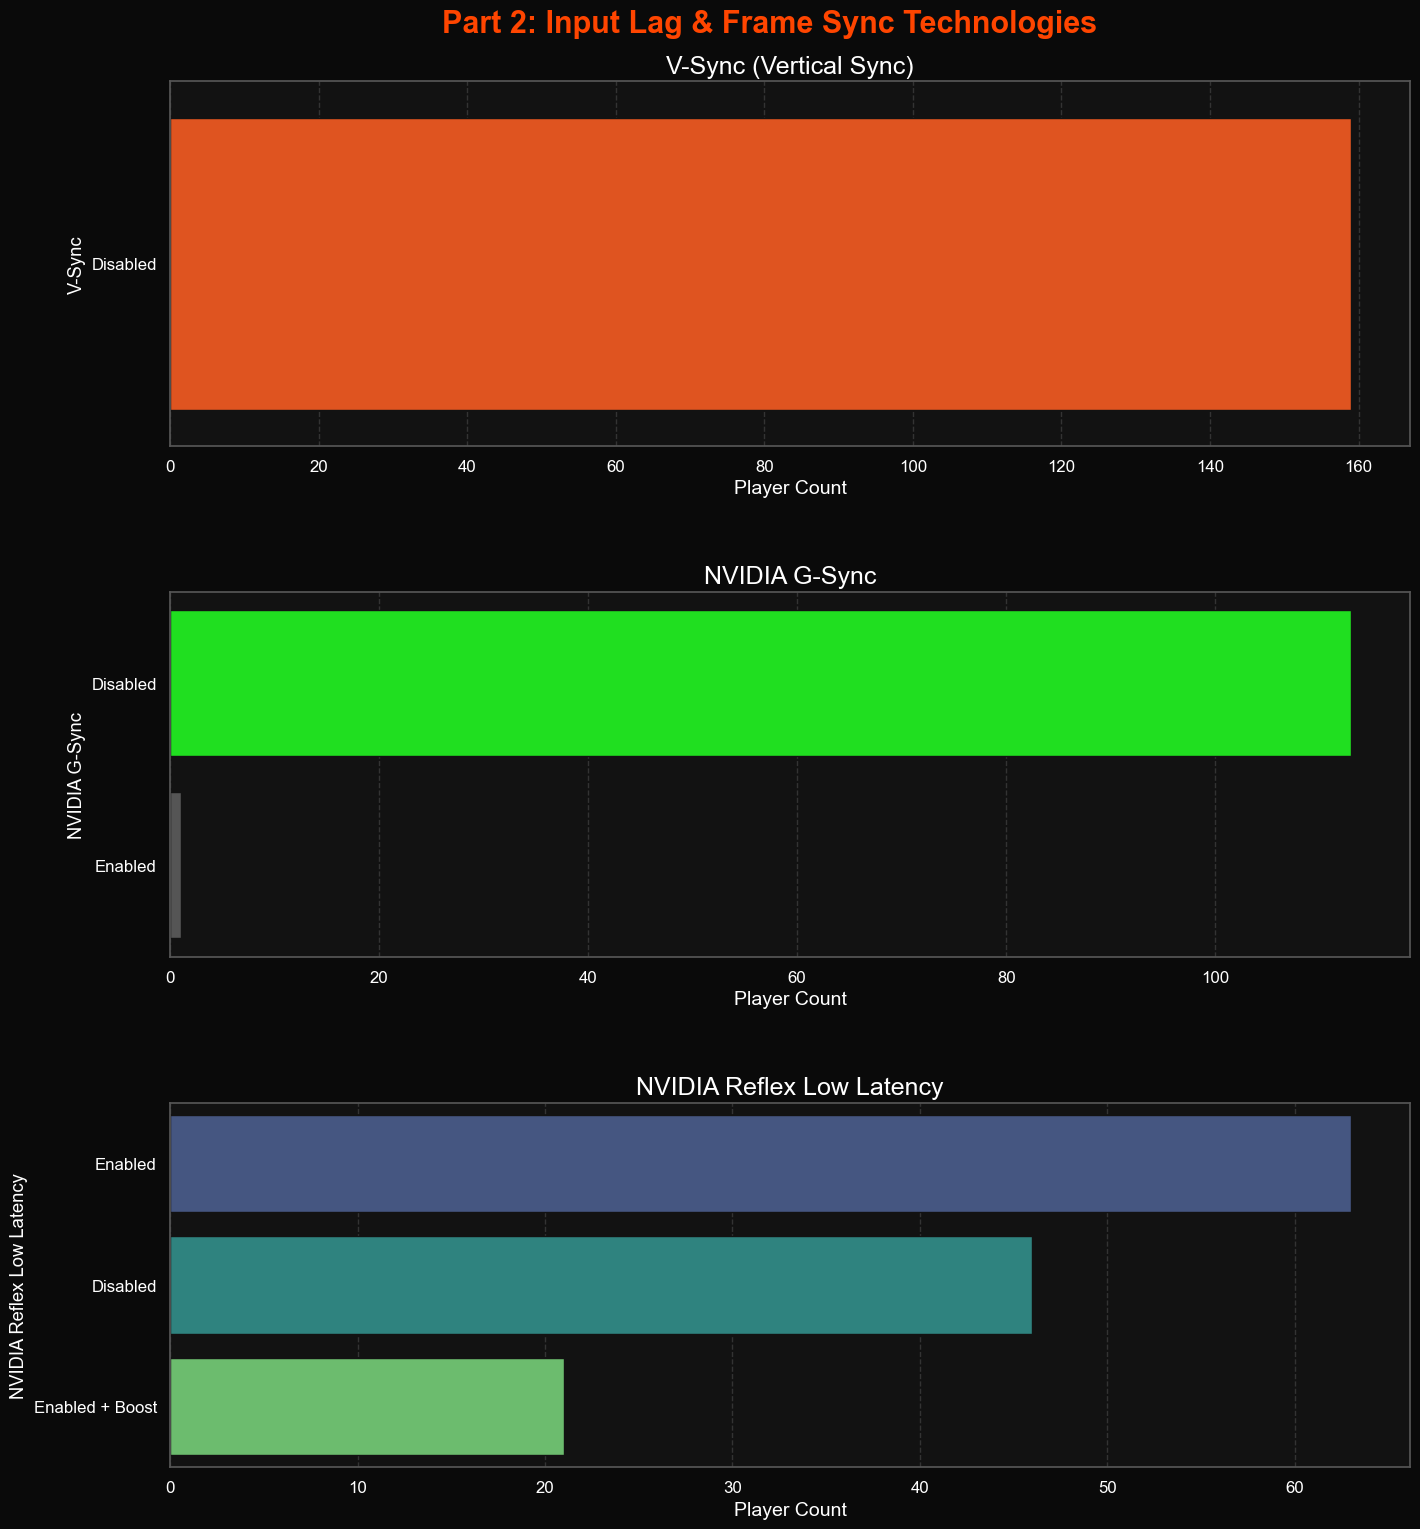

In [23]:
# ==========================================
# ⚙️ Cell 6.2 (重制版): 输入延迟与同步机制 (The Latency War)
# ==========================================

fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Part 2: Input Lag & Frame Sync Technologies', fontsize=22, fontweight='bold', color='#FF4500', y=0.92)

# --- 1. V-Sync (过滤 Unknown) ---
df_vsync = df_pro[df_pro['V-Sync'] != 'Unknown']
sns.countplot(data=df_vsync, y='V-Sync', order=df_vsync['V-Sync'].value_counts().index, palette=['#FF4500', '#555555'], ax=axes[0], edgecolor='#121212')
axes[0].set_title('V-Sync (Vertical Sync)', fontsize=18)
axes[0].set_xlabel('Player Count', fontsize=14)

# --- 2. G-Sync (过滤 Unknown) ---
df_gsync = df_pro[df_pro['NVIDIA G-Sync'] != 'Unknown']
sns.countplot(data=df_gsync, y='NVIDIA G-Sync', order=df_gsync['NVIDIA G-Sync'].value_counts().index, palette=['#00FF00', '#555555'], ax=axes[1], edgecolor='#121212')
axes[1].set_title('NVIDIA G-Sync', fontsize=18)
axes[1].set_xlabel('Player Count', fontsize=14)

# --- 3. NVIDIA Reflex (过滤 Unknown) ---
df_reflex = df_pro[df_pro['NVIDIA Reflex Low Latency'] != 'Unknown']
sns.countplot(data=df_reflex, y='NVIDIA Reflex Low Latency', order=df_reflex['NVIDIA Reflex Low Latency'].value_counts().index, palette='viridis', ax=axes[2], edgecolor='#121212')
axes[2].set_title('NVIDIA Reflex Low Latency', fontsize=18)
axes[2].set_xlabel('Player Count', fontsize=14)

plt.subplots_adjust(hspace=0.4)
plt.show()

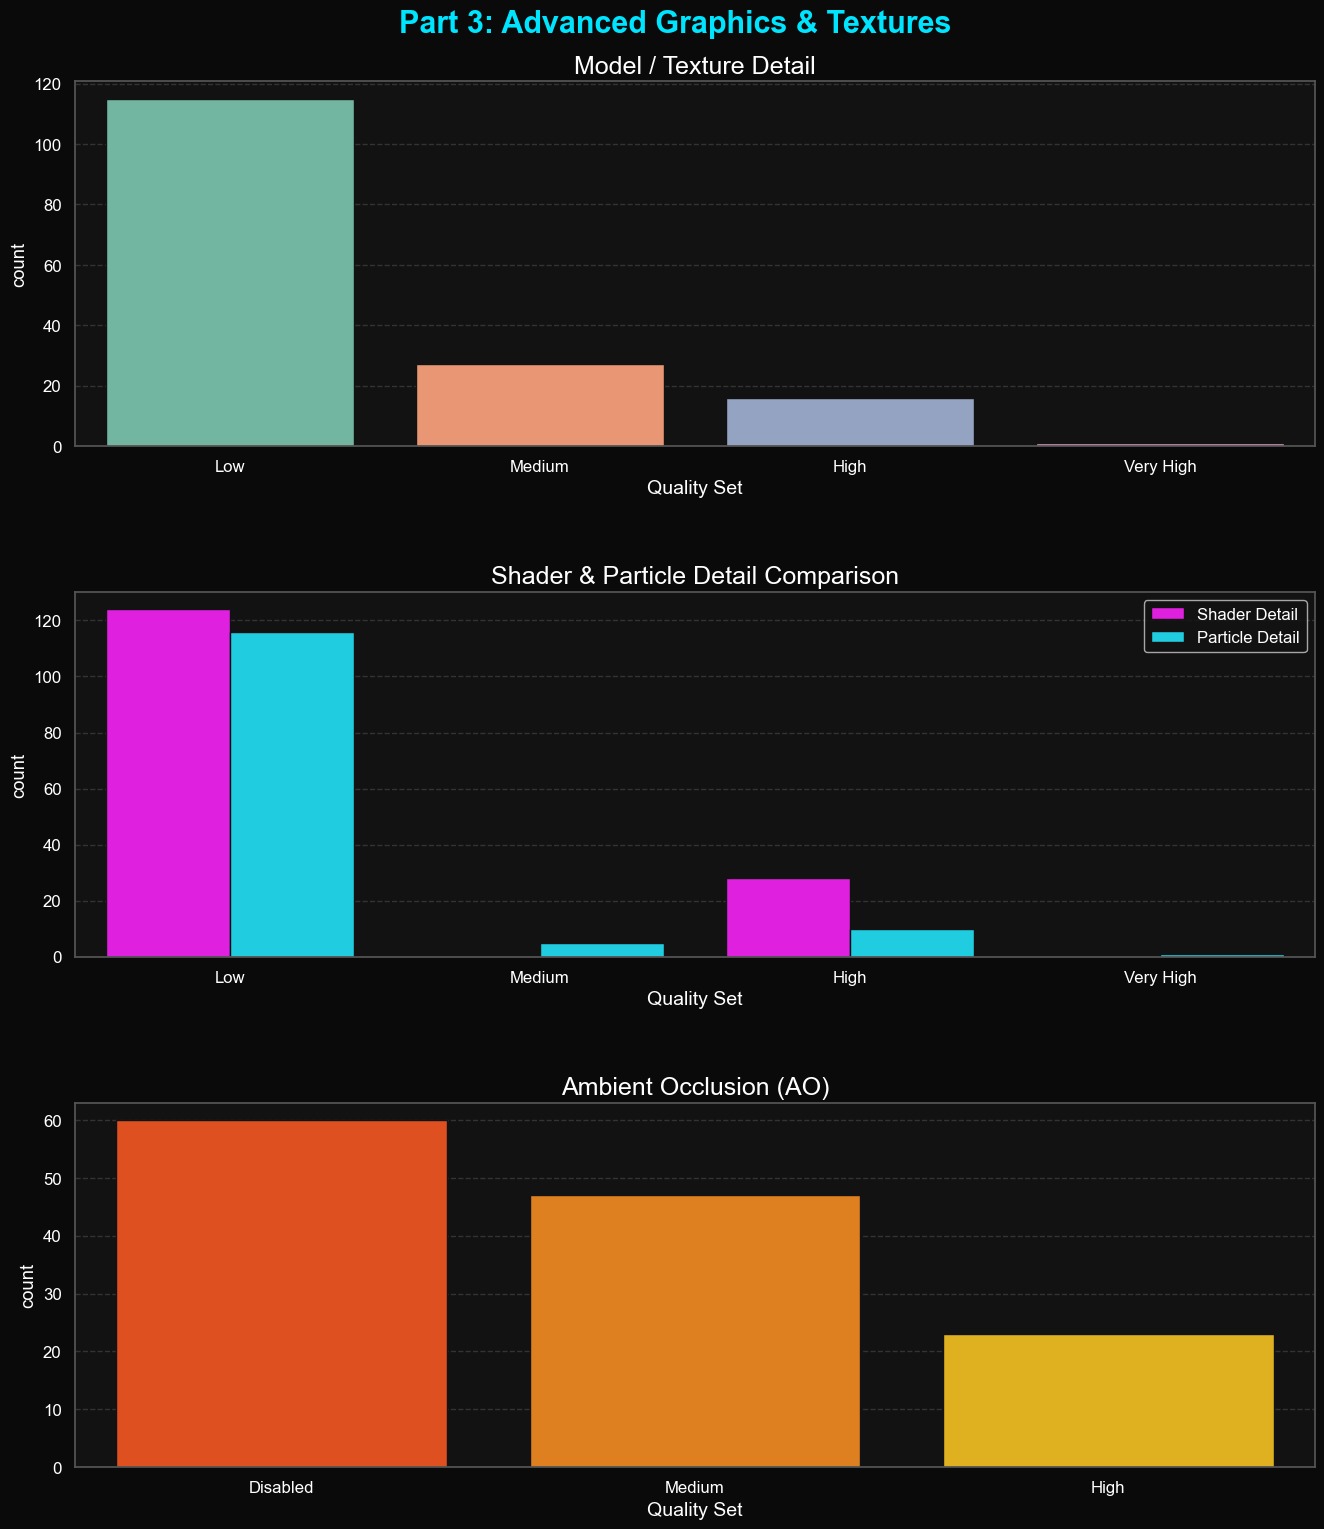

In [24]:
# ==========================================
# ⚙️ Cell 6.3 (重制版): 高级画质细节探秘 (FPS vs Visibility)
# ==========================================

fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Part 3: Advanced Graphics & Textures', fontsize=22, fontweight='bold', color='#00E5FF', y=0.92)

# --- 1. Model / Texture Detail ---
df_model = df_pro[df_pro['Model / Texture Detail'] != 'Unknown']
sns.countplot(data=df_model, x='Model / Texture Detail', order=df_model['Model / Texture Detail'].value_counts().index, palette='Set2', ax=axes[0], edgecolor='#121212')
axes[0].set_title('Model / Texture Detail', fontsize=18)
axes[0].set_xlabel('Quality Set', fontsize=14)

# --- 2. Shader & Particle Detail ---
# 提取并融化数据，同时过滤掉 Unknown
df_shader_particle = df_pro[['Shader Detail', 'Particle Detail']].melt(var_name='Setting Type', value_name='Quality')
df_sp_clean = df_shader_particle[df_shader_particle['Quality'] != 'Unknown']

sns.countplot(data=df_sp_clean, x='Quality', hue='Setting Type', 
              order=['Low', 'Medium', 'High', 'Very High'], # 强制按从低到高的逻辑排序
              palette=['#FF00FF', '#00E5FF'], ax=axes[1], edgecolor='#121212')
axes[1].set_title('Shader & Particle Detail Comparison', fontsize=18)
axes[1].set_xlabel('Quality Set', fontsize=14)
axes[1].legend(fontsize=12)

# --- 3. Ambient Occlusion (AO) ---
df_ao = df_pro[df_pro['Ambient Occlusion'] != 'Unknown']
sns.countplot(data=df_ao, x='Ambient Occlusion', order=df_ao['Ambient Occlusion'].value_counts().index, palette='autumn', ax=axes[2], edgecolor='#121212')
axes[2].set_title('Ambient Occlusion (AO)', fontsize=18)
axes[2].set_xlabel('Quality Set', fontsize=14)

plt.subplots_adjust(hspace=0.4)
plt.show()

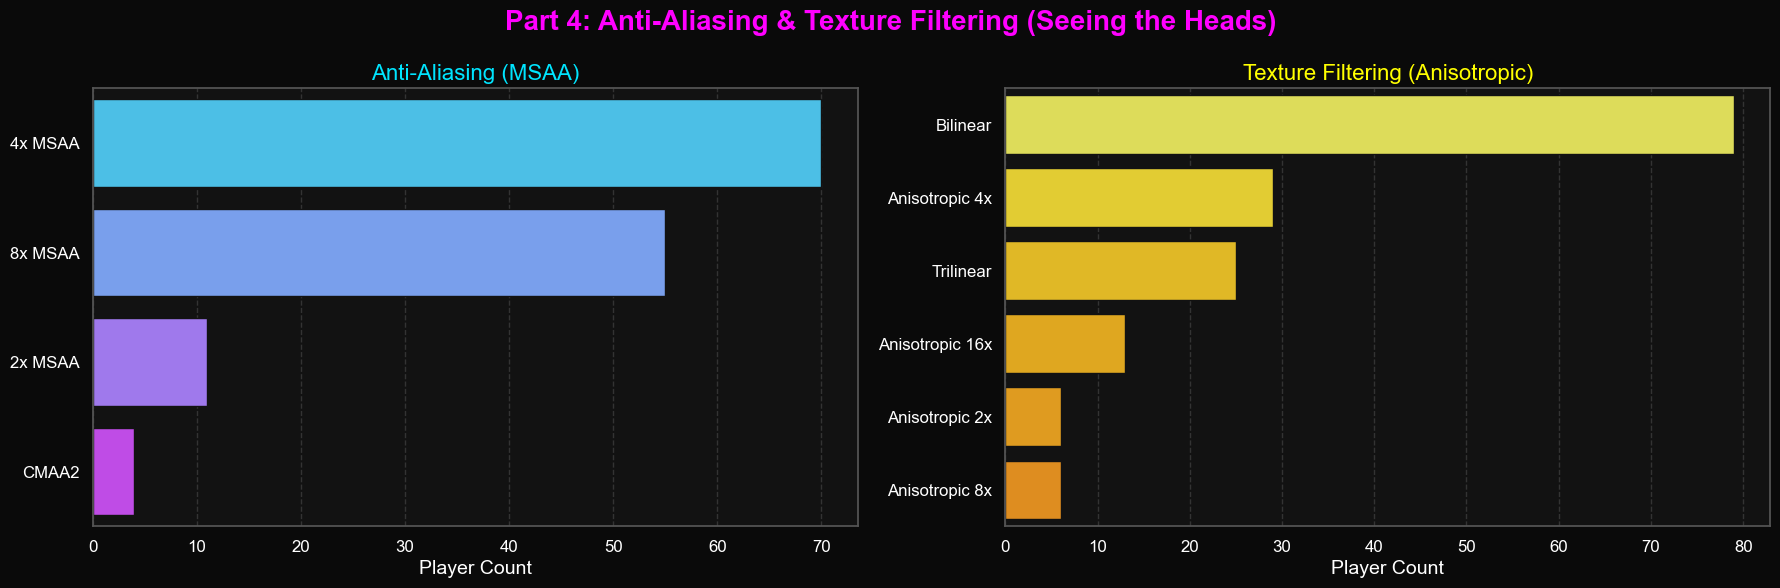

🎯 使用 4x MSAA 的职业选手占比: 38.0%


In [25]:
# ==========================================
# ⚙️ Cell 6.4: 边缘清晰度与抗锯齿 (The Edge Clarity Meta)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 再次确保忽略烦人的粉色警告
warnings.filterwarnings('ignore', category=FutureWarning)

# 创建 1行2列 的宽幅画布
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Part 4: Anti-Aliasing & Texture Filtering (Seeing the Heads)', fontsize=20, fontweight='bold', color='#FF00FF')

# --- 1. Multisampling Anti-Aliasing Mode (MSAA 抗锯齿) ---
# 过滤掉 Unknown 并画水平条形图让长标签更好看
df_msaa = df_pro[df_pro['Multisampling Anti-Aliasing Mode'] != 'Unknown']
sns.countplot(data=df_msaa, y='Multisampling Anti-Aliasing Mode', 
              order=df_msaa['Multisampling Anti-Aliasing Mode'].value_counts().index, 
              palette='cool', ax=axes[0], edgecolor='#121212')
axes[0].set_title('Anti-Aliasing (MSAA)', fontsize=16, color='#00E5FF')
axes[0].set_xlabel('Player Count', fontsize=14)
axes[0].set_ylabel('')

# --- 2. Texture Filtering Mode (各向异性过滤) ---
df_texture = df_pro[df_pro['Texture Filtering Mode'] != 'Unknown']
sns.countplot(data=df_texture, y='Texture Filtering Mode', 
              order=df_texture['Texture Filtering Mode'].value_counts().index, 
              palette='Wistia', ax=axes[1], edgecolor='#121212')
axes[1].set_title('Texture Filtering (Anisotropic)', fontsize=16, color='#FFFF00')
axes[1].set_xlabel('Player Count', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 打印一下具体的比例，印证你的 4x 猜想
msaa_4x = len(df_msaa[df_msaa['Multisampling Anti-Aliasing Mode'].str.contains('4x', na=False, case=False)])
print(f"🎯 使用 4x MSAA 的职业选手占比: {(msaa_4x/len(df_msaa))*100:.1f}%")

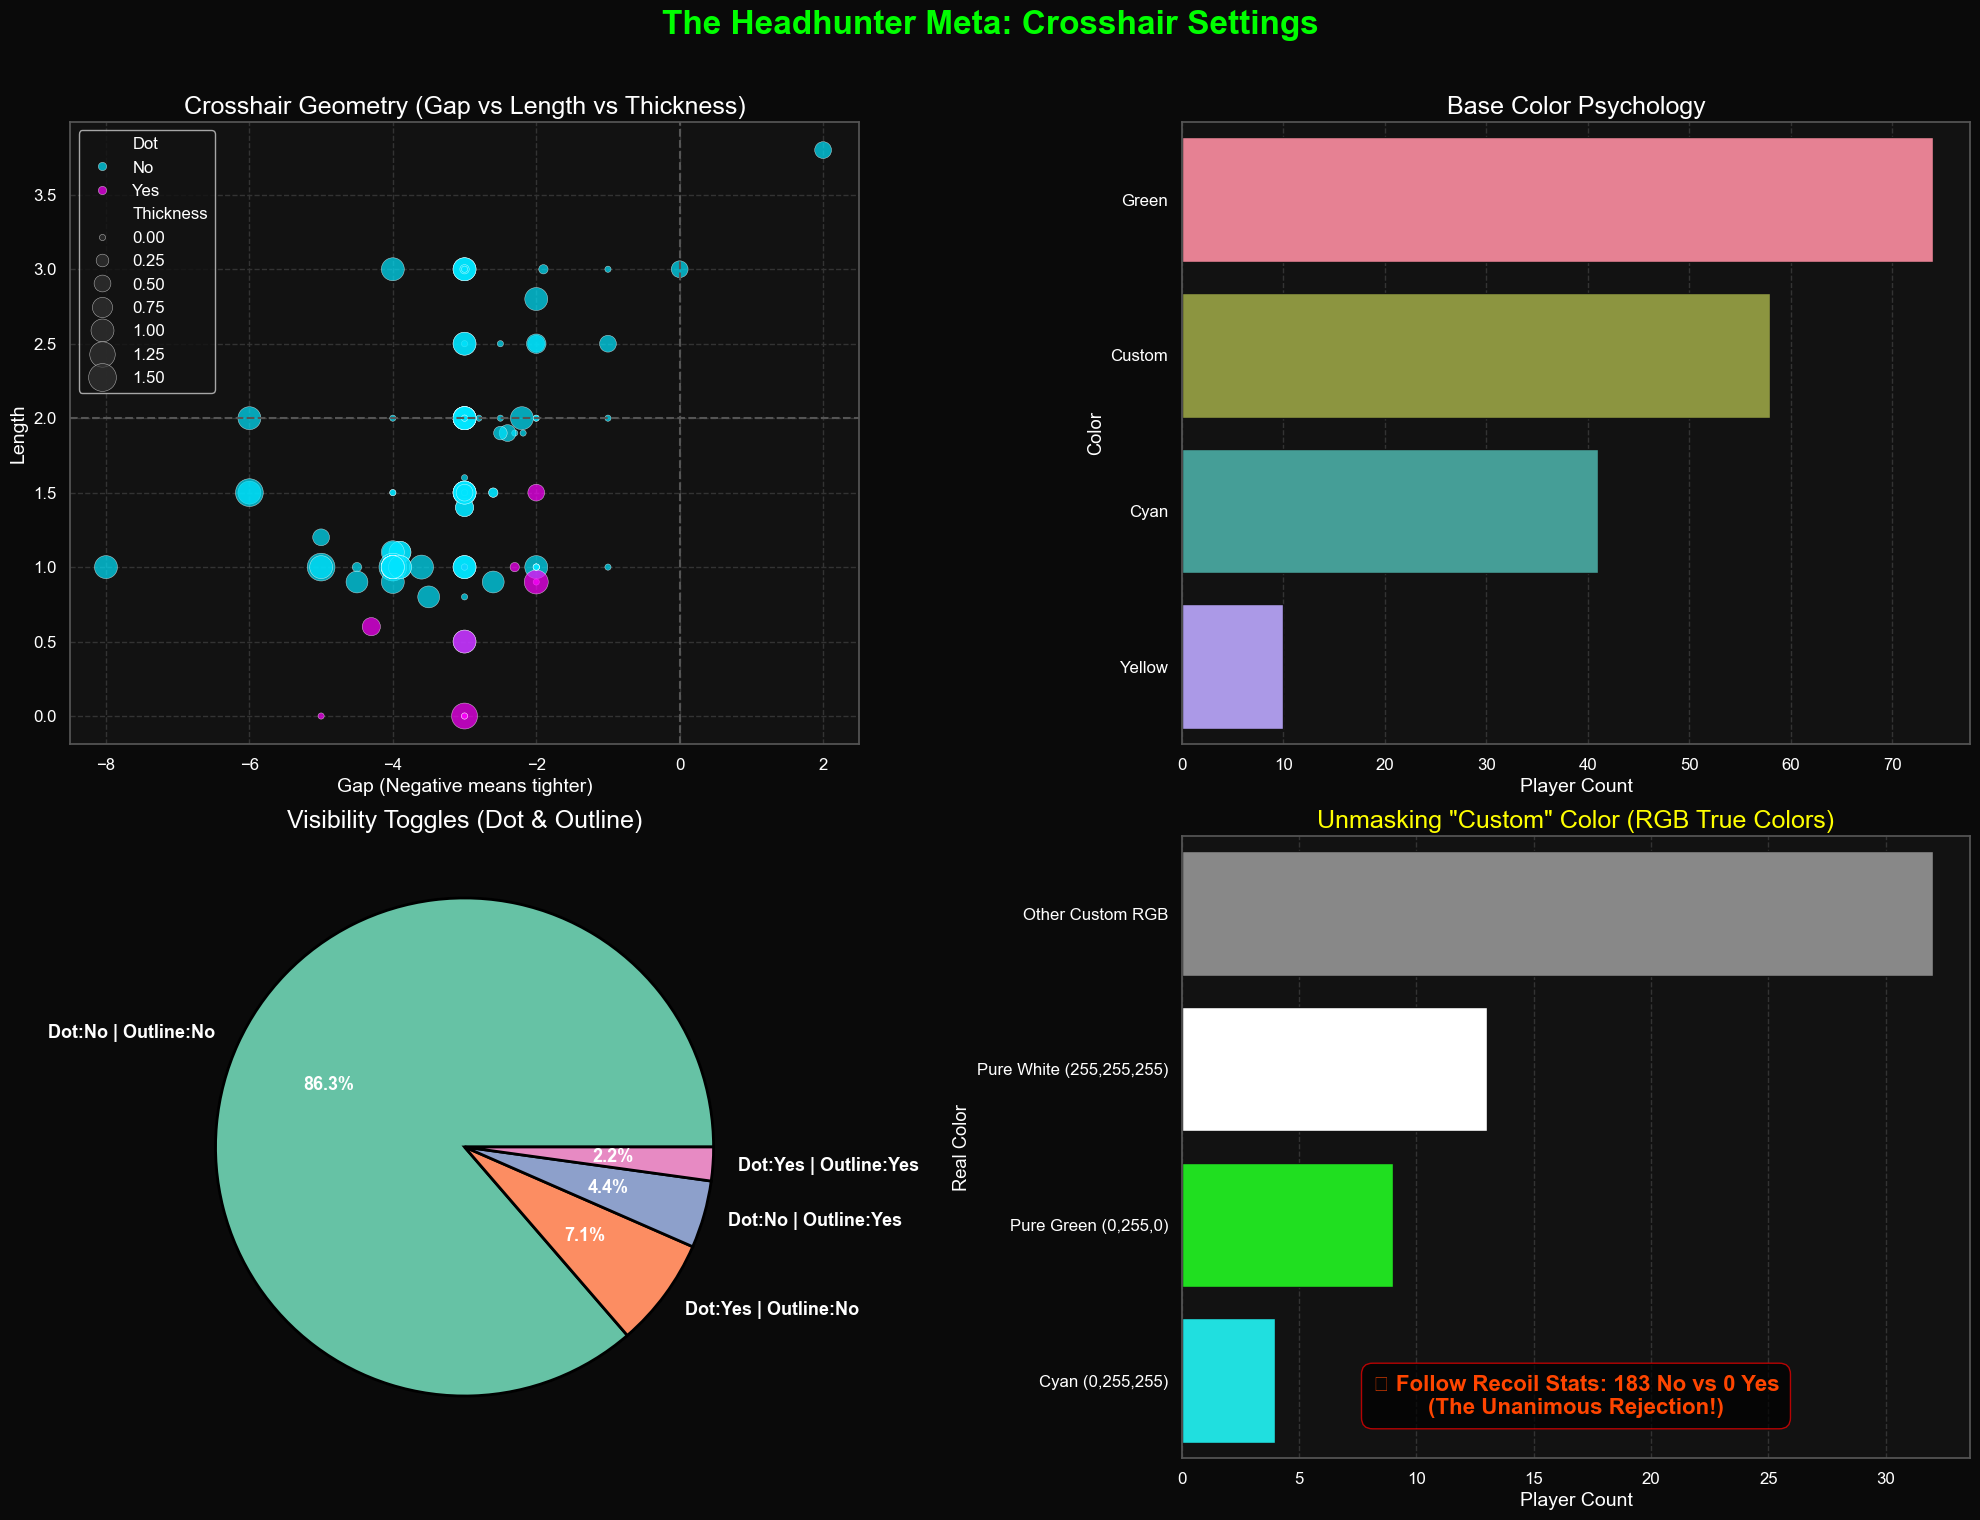

In [31]:
# ==========================================
# 🎯 Cell 7 (重制版): 爆头玄学与 Custom 颜色扒皮
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

# 彻底屏蔽所有烦人的警告 (包括 palette 警告)
warnings.filterwarnings('ignore')

# 1. 读取基础表和 RAW 表
df_pro = pd.read_csv("cs2_pro_2026_Active_Enhanced.csv")
df_raw = pd.read_csv("cs2_pro_detailed_RAW.csv", low_memory=False)

# 2. 【核心优化】不仅捞回 Follow Recoil，直接去 RAW 表里把 RGB 捞回来！
cols_to_fetch = ['Player', 'Follow Recoil', 'Red', 'Green', 'Blue']
df_extra = df_raw[cols_to_fetch].drop_duplicates(subset=['Player'])

# 如果之前捞过，先删掉旧的防止冲突
df_pro = df_pro.drop(columns=[c for c in cols_to_fetch if c in df_pro.columns and c != 'Player'], errors='ignore')
df_pro = pd.merge(df_pro, df_extra, on='Player', how='left')

# 3. 强制转换几何和颜色数据为数值型
for col in['Gap', 'Length', 'Thickness', 'Red', 'Green', 'Blue']:
    df_pro[col] = pd.to_numeric(df_pro[col], errors='coerce')

# 清理空值以备画图
df_crosshair = df_pro.dropna(subset=['Gap', 'Length', 'Thickness', 'Color']).copy()

# ================= 画图开始 =================
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('The Headhunter Meta: Crosshair Settings', fontsize=24, fontweight='bold', color='#00FF00', y=0.95)

# --- 图 1: 准星几何形态矩阵 (左上) ---
sns.scatterplot(data=df_crosshair, x='Gap', y='Length', size='Thickness', hue='Dot', 
                sizes=(20, 400), alpha=0.7, palette=['#00E5FF', '#FF00FF'], ax=axes[0, 0], edgecolor='w')
axes[0, 0].set_title('Crosshair Geometry (Gap vs Length vs Thickness)', fontsize=18)
axes[0, 0].set_xlabel('Gap (Negative means tighter)', fontsize=14)
axes[0, 0].set_ylabel('Length', fontsize=14)
axes[0, 0].axvline(0, color='#555555', linestyle='--')
axes[0, 0].axhline(2.0, color='#555555', linestyle='--')

# --- 图 2: 宏观色彩分布 (右上) ---
color_counts = df_crosshair['Color'].value_counts()
sns.barplot(x=color_counts.values, y=color_counts.index, palette='husl', ax=axes[0, 1], edgecolor='#121212')
axes[0, 1].set_title('Base Color Psychology', fontsize=18)
axes[0, 1].set_xlabel('Player Count', fontsize=14)

# --- 图 3: 可见性开关 (左下) ---
df_crosshair['Toggle Config'] = 'Dot:' + df_crosshair['Dot'].astype(str) + ' | Outline:' + df_crosshair['Outline'].astype(str)
toggle_counts = df_crosshair['Toggle Config'].value_counts()
axes[1, 0].pie(toggle_counts, labels=toggle_counts.index, autopct='%1.1f%%', 
               colors=sns.color_palette("Set2", len(toggle_counts)), 
               textprops={'color':"w", 'fontweight':'bold', 'fontsize':13}, wedgeprops={'edgecolor': 'black', 'linewidth':2})
axes[1, 0].set_title('Visibility Toggles (Dot & Outline)', fontsize=18)

# --- 图 4: 【全新替换】Custom 自定义颜色的 RGB 扒皮 (右下) ---
# 提取所有选择了 Custom 的玩家
custom_df = df_crosshair[df_crosshair['Color'] == 'Custom'].dropna(subset=['Red', 'Green', 'Blue'])

# 定义一个函数，直接翻译 RGB 对应的真实颜色
def get_real_color(r, g, b):
    if r == 255 and g == 255 and b == 255: return 'Pure White (255,255,255)'
    if r == 255 and g == 0 and b == 255: return 'Magenta/Pink (255,0,255)'
    if r == 0 and g == 255 and b == 255: return 'Cyan (0,255,255)'
    if r == 0 and g == 255 and b == 0: return 'Pure Green (0,255,0)'
    return 'Other Custom RGB'

custom_df['Real Color'] = custom_df.apply(lambda row: get_real_color(row['Red'], row['Green'], row['Blue']), axis=1)
real_color_counts = custom_df['Real Color'].value_counts()

# 为了视觉震撼，我们用它们真实的颜色来画柱状图！
custom_palette = {'Pure White (255,255,255)': '#FFFFFF', 'Magenta/Pink (255,0,255)': '#FF00FF', 
                  'Cyan (0,255,255)': '#00FFFF', 'Pure Green (0,255,0)': '#00FF00', 'Other Custom RGB': '#888888'}

sns.barplot(x=real_color_counts.values, y=real_color_counts.index, 
            palette=[custom_palette.get(x, '#888888') for x in real_color_counts.index], 
            ax=axes[1, 1], edgecolor='#121212')
axes[1, 1].set_title('Unmasking "Custom" Color (RGB True Colors)', fontsize=18, color='#FFFF00')
axes[1, 1].set_xlabel('Player Count', fontsize=14)

# 【彩蛋】在右下角图表的空白处，用一段血红色的文字宣判 Follow Recoil 的死刑！
recoil_no_count = len(df_pro[df_pro['Follow Recoil'] == 'No'])
axes[1, 1].text(0.5, 0.1, f"🔥 Follow Recoil Stats: {recoil_no_count} No vs 0 Yes\n(The Unanimous Rejection!)", 
                transform=axes[1, 1].transAxes, fontsize=16, color='#FF4500', fontweight='bold', 
                ha='center', va='center', bbox=dict(facecolor='black', alpha=0.7, edgecolor='red', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# 再次保存包含 RGB 最新数据的终极增强表
df_pro.to_csv("cs2_pro_2026_Active_Enhanced.csv", index=False, encoding='utf-8-sig')

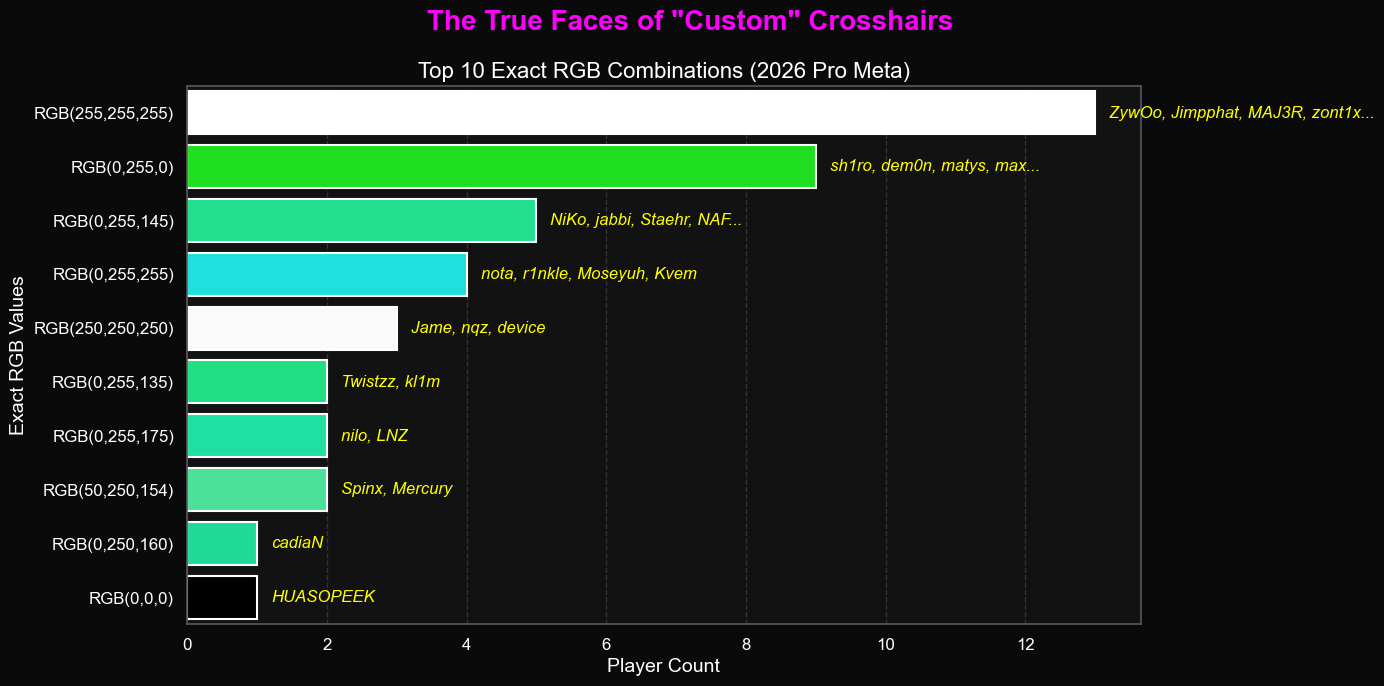

In [30]:
# ==========================================
# 🎨 Cell 7.5 (修复版): 真正的底裤——神秘的 Custom RGB 颜色大揭秘
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 把所有选择了 Custom 颜色的哥们揪出来
df_pro = pd.read_csv("cs2_pro_2026_Active_Enhanced.csv")
custom_df = df_pro[df_pro['Color'] == 'Custom'].dropna(subset=['Red', 'Green', 'Blue']).copy()

# 2. 确保 RGB 是整数
custom_df['Red'] = custom_df['Red'].astype(int)
custom_df['Green'] = custom_df['Green'].astype(int)
custom_df['Blue'] = custom_df['Blue'].astype(int)

# 3. 把 RGB 组合成标签
custom_df['RGB_Label'] = 'RGB(' + custom_df['Red'].astype(str) + ',' + custom_df['Green'].astype(str) + ',' + custom_df['Blue'].astype(str) + ')'

# 4. 转换成 Hex 颜色画图
def rgb_to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(max(0, min(r, 255)), max(0, min(g, 255)), max(0, min(b, 255))).upper()

custom_df['Hex_Color'] = custom_df.apply(lambda row: rgb_to_hex(row['Red'], row['Green'], row['Blue']), axis=1)

# 5. 统计 Top 10，【关键修复】重置索引 (reset_index) 让它们变成标准的 0, 1, 2...
top_custom_colors = custom_df.groupby(['RGB_Label', 'Hex_Color']).size().reset_index(name='Player Count')
top_custom_colors = top_custom_colors.sort_values(by='Player Count', ascending=False).head(10).reset_index(drop=True)

# ================= 画图开始 =================
fig, ax = plt.subplots(figsize=(14, 7)) # 稍微加宽一点给名字留空间
fig.suptitle('The True Faces of "Custom" Crosshairs', fontsize=20, fontweight='bold', color='#FF00FF')

# 画柱状图，加上白色描边
sns.barplot(data=top_custom_colors, x='Player Count', y='RGB_Label', 
            palette=top_custom_colors['Hex_Color'].tolist(), 
            ax=ax, edgecolor='#FFFFFF', linewidth=1.5)

ax.set_title('Top 10 Exact RGB Combinations (2026 Pro Meta)', fontsize=16)
ax.set_xlabel('Player Count', fontsize=14)
ax.set_ylabel('Exact RGB Values', fontsize=14)

# 【完美对齐的魔法】直接用行号 (i) 作为 Y 轴高度！
for i, row in top_custom_colors.iterrows():
    # 找出用这个颜色的所有玩家
    players = custom_df[custom_df['RGB_Label'] == row['RGB_Label']]['Player'].tolist()
    # 最多显示前 4 个名字
    player_text = ", ".join(players[:4]) + ("..." if len(players) > 4 else "")
    
    # x 位置在柱子右边加 0.2，y 位置就是纯粹的序号 i
    ax.text(row['Player Count'] + 0.2, i, player_text, va='center', fontsize=12, color='#FFFF00', style='italic')

plt.tight_layout()
plt.show()

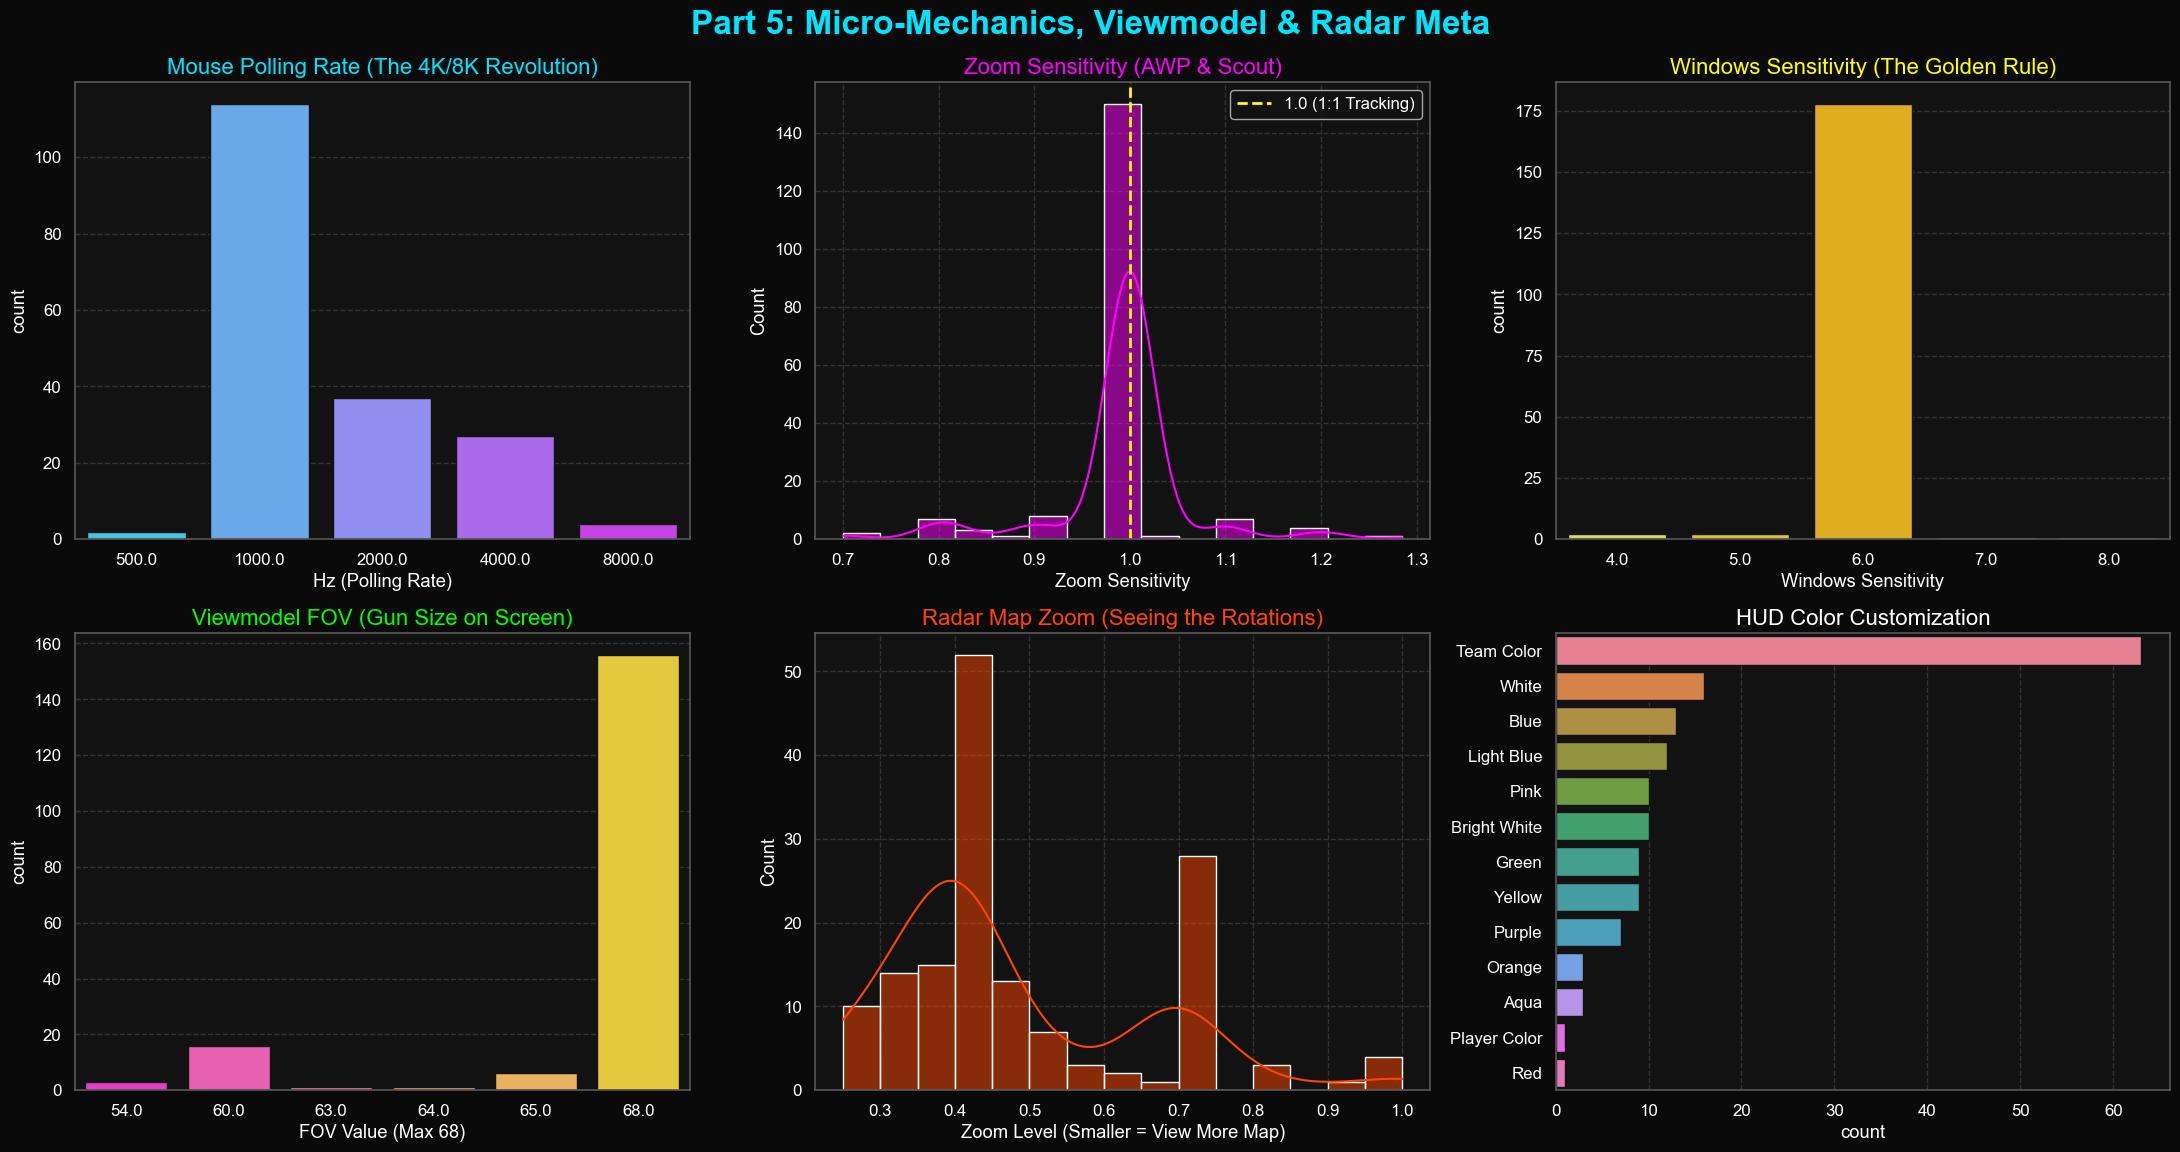

✅ EDA (探索性分析) 全维度彻底通关！数据已保存为 cs2_pro_2026_Active_Final.csv！


In [32]:
# ==========================================
# ⚙️ Cell 8: The Final Details (微操、持枪视角与雷达 UI)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

warnings.filterwarnings('ignore')
df_pro = pd.read_csv("cs2_pro_2026_Active_Enhanced.csv")

# 1. 数据清洗：确保数值型参数被正确识别
for col in['Hz', 'Zoom Sensitivity', 'Windows Sensitivity', 'FOV', 'Radar Map Zoom']:
    df_pro[col] = pd.to_numeric(df_pro[col], errors='coerce')

# 创建 2行3列 的画布
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Part 5: Micro-Mechanics, Viewmodel & Radar Meta', fontsize=24, fontweight='bold', color='#00E5FF', y=0.96)

# --- [行 1, 列 1]: 鼠标回报率 (Hz) 硬件革命 ---
df_hz = df_pro.dropna(subset=['Hz'])
sns.countplot(data=df_hz, x='Hz', palette='cool', ax=axes[0,0], edgecolor='#121212')
axes[0,0].set_title('Mouse Polling Rate (The 4K/8K Revolution)', fontsize=16, color='#00E5FF')
axes[0,0].set_xlabel('Hz (Polling Rate)')

# --- [行 1, 列 2]: 狙击手微调 (Zoom Sensitivity) ---
df_zoom = df_pro.dropna(subset=['Zoom Sensitivity'])
sns.histplot(df_zoom['Zoom Sensitivity'], bins=15, kde=True, color='#FF00FF', ax=axes[0,1])
axes[0,1].set_title('Zoom Sensitivity (AWP & Scout)', fontsize=16, color='#FF00FF')
axes[0,1].axvline(1.0, color='#FFFF00', linestyle='--', linewidth=2, label='1.0 (1:1 Tracking)')
axes[0,1].legend()

# --- [行 1, 列 3]: 绝对的祖训 (Windows Sensitivity) ---
df_win = df_pro.dropna(subset=['Windows Sensitivity'])
sns.countplot(data=df_win, x='Windows Sensitivity', palette='Wistia', ax=axes[0,2], edgecolor='#121212')
axes[0,2].set_title('Windows Sensitivity (The Golden Rule)', fontsize=16, color='#FFFF00')

# ---[行 2, 列 1]: 视角模型 (Viewmodel FOV) ---
df_fov = df_pro.dropna(subset=['FOV'])
sns.countplot(data=df_fov, x='FOV', palette='spring', ax=axes[1,0], edgecolor='#121212')
axes[1,0].set_title('Viewmodel FOV (Gun Size on Screen)', fontsize=16, color='#00FF00')
axes[1,0].set_xlabel('FOV Value (Max 68)')

# ---[行 2, 列 2]: 上帝之眼 (Radar Map Zoom) ---
df_radar = df_pro.dropna(subset=['Radar Map Zoom'])
sns.histplot(df_radar['Radar Map Zoom'], bins=15, kde=True, color='#FF4500', ax=axes[1,1])
axes[1,1].set_title('Radar Map Zoom (Seeing the Rotations)', fontsize=16, color='#FF4500')
axes[1,1].set_xlabel('Zoom Level (Smaller = View More Map)')

# --- [行 2, 列 3]: 界面个性化 (HUD Color) ---
df_hud = df_pro.dropna(subset=['HUD Color'])
sns.countplot(data=df_hud, y='HUD Color', order=df_hud['HUD Color'].value_counts().index, palette='husl', ax=axes[1,2], edgecolor='#121212')
axes[1,2].set_title('HUD Color Customization', fontsize=16)
axes[1,2].set_ylabel('')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# 为后续 AI 建模保存最终极其完美的版本
df_pro.to_csv("cs2_pro_2026_Active_Final.csv", index=False, encoding='utf-8-sig')
print("✅ EDA (探索性分析) 全维度彻底通关！数据已保存为 cs2_pro_2026_Active_Final.csv！")

>>> [系统日志] 启动 2026 CS2 五大现代战术流派聚类 (K=5)...


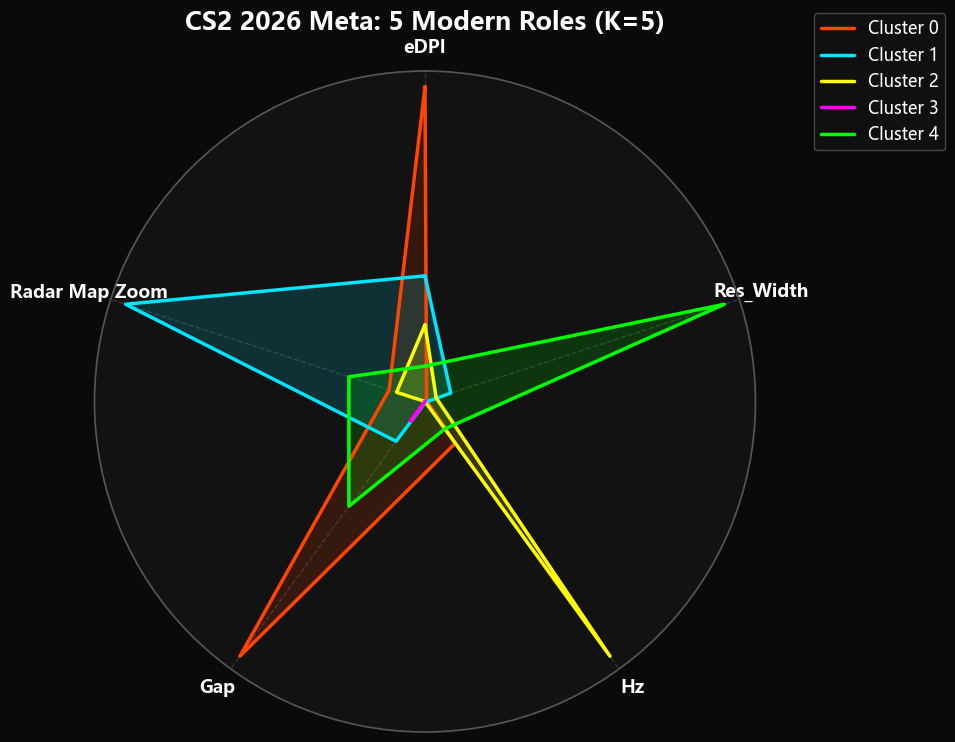


🎯 [五大门派核心特征与代表选手挖掘报告] 🎯

🟢 【Cluster 0 阵营特征均值】:


,eDPI,Res_Width,Hz,Gap,Radar Map Zoom
0,1139.82,1254.67,1791.67,-2.41,0.42


👑 完美代表选手 (Top 3): Kvem, try, Graviti

🟢 【Cluster 1 阵营特征均值】:


,eDPI,Res_Width,Hz,Gap,Radar Map Zoom
1,913.87,1305.81,1225.81,-3.44,0.75


👑 完美代表选手 (Top 3): Gizmy, xiELO, molodoy

🟢 【Cluster 2 阵营特征均值】:


...

👑 完美代表选手 (Top 3): insani, Frozen, z4kr

🟢 【Cluster 3 阵营特征均值】:


,eDPI,Res_Width,Hz,Gap,Radar Map Zoom
3,763.69,1251.2,1216.67,-3.54,0.38


👑 完美代表选手 (Top 3): karrigan, nilo, Staehr

🟢 【Cluster 4 阵营特征均值】:


,eDPI,Res_Width,Hz,Gap,Radar Map Zoom
4,806.0,1885.0,1593.75,-3.13,0.47


👑 完美代表选手 (Top 3): oSee, YEKINDAR, xKacpersky


In [36]:
# ==========================================
# 🧠 Phase 4 V2.0: 现代 CS2 五大门派聚类 & 代表选手挖掘
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from IPython.display import display

# 🔧 彻底修复中文字体显示问题 (Windows 适用)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

print(">>> [系统日志] 启动 2026 CS2 五大现代战术流派聚类 (K=5)...")
features = ['eDPI', 'Res_Width', 'Hz', 'Gap', 'Radar Map Zoom']

# 提取特征，并保留原表的 Player 名字用于最后找人 (假设你的选手名字列叫 'Player'，如果是别的请修改)
player_col = 'Player' if 'Player' in df_pro.columns else df_pro.columns[0]
X = df_pro[features + [player_col]].dropna().copy()

# 1. 数据标准化
scaler = StandardScaler()
X_features_scaled = scaler.fit_transform(X[features])

# 2. 执行 K=5 聚类
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=7800, n_init=10)
clusters = kmeans.fit_predict(X_features_scaled)
X['Cluster'] = clusters

# ==========================================
# 🌟 高阶技巧：计算欧氏距离，找出每个门派最纯正的代表选手
# ==========================================
# transform 方法直接返回每个样本到 5 个中心点的距离
distances = kmeans.transform(X_features_scaled)
# 提取每个人到他所属那个流派中心点的距离 (距离越近，越是这个流派的终极代表)
X['Distance_to_Center'] = [distances[i, cluster_id] for i, cluster_id in enumerate(clusters)]

# 3. 获取中心点绝对数值
cluster_centers_real = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_), 
    columns=features
)

# 动态定义五大门派的颜色 (加入赛博绿)
colors =["#FF4500", "#00E5FF", "#FFFF00", "#FF00FF", "#00FF00"]
# 这里暂时使用 Cluster 0~4，具体谁是 IGL 谁是 AWPer，等看数据再对号入座
cluster_names = [f"Cluster {i}" for i in range(optimal_k)]

# 4. 绘制五芒星赛博雷达图
min_max_scaler = MinMaxScaler()
centers_normalized = min_max_scaler.fit_transform(cluster_centers_real)
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for i in range(optimal_k):
    values = centers_normalized[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2.5, label=cluster_names[i])
    ax.fill(angles, values, color=colors[i], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=13, fontweight='bold', color='white')
ax.set_yticks([])
ax.spines['polar'].set_color('#555555')

plt.title('CS2 2026 Meta: 5 Modern Roles (K=5)', size=18, y=1.05, fontweight='bold', color='white')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), facecolor='#121212', edgecolor='#555555', labelcolor='white')
plt.tight_layout()
plt.show()

# 5. 输出中心矩阵，并挖掘代表选手
print("\n" + "="*60)
print("🎯 [五大门派核心特征与代表选手挖掘报告] 🎯")
print("="*60)

for i in range(optimal_k):
    print(f"\n🟢 【Cluster {i} 阵营特征均值】:")
    # 打印该门派的特征均值
    display(pd.DataFrame(cluster_centers_real.iloc[i]).T.round(2))
    
    # 寻找距离中心点最近的 3 个人（最标准的代表）
    top_representatives = X[X['Cluster'] == i].sort_values(by='Distance_to_Center').head(3)
    players = top_representatives[player_col].tolist()
    print(f"👑 完美代表选手 (Top 3): {', '.join(players)}")

>>> [系统日志] 正在计算 2026 CS2 职业选手参数的底层相关性...


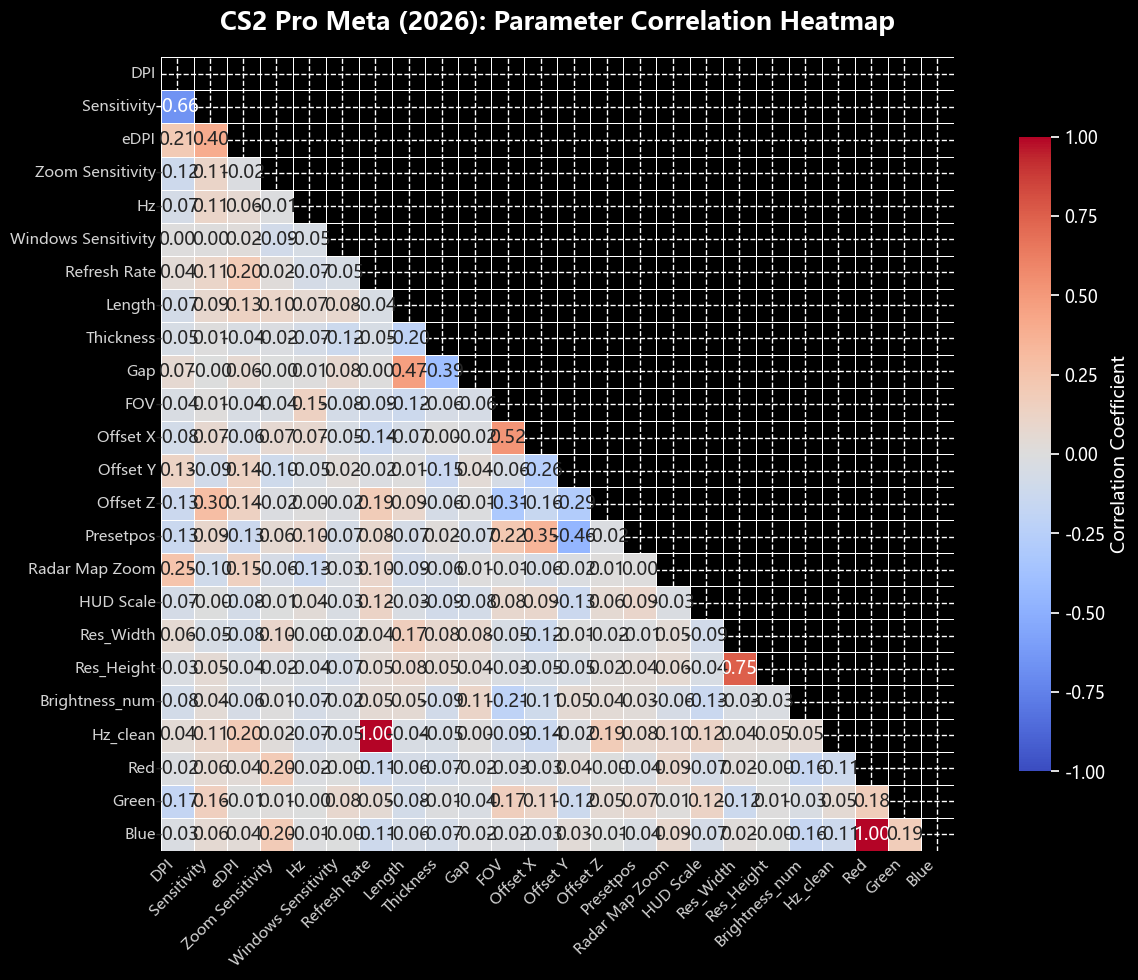


🔗 [AI 核心洞察] 最强数据关联性 TOP 提取
🔴 强正相关: [Hz_clean] 与 [Refresh Rate] -> 1.00
🔴 强正相关: [Blue] 与 [Red] -> 1.00
🔴 强正相关: [Res_Height] 与 [Res_Width] -> 0.75
🔵 强负相关: [DPI] 与 [Sensitivity] -> -0.66
🔴 强正相关: [FOV] 与 [Offset X] -> 0.52
⚪ 弱相关: [Gap] 与 [Length] -> 0.47
⚪ 弱相关: [Offset Y] 与 [Presetpos] -> -0.46
⚪ 弱相关: [Sensitivity] 与 [eDPI] -> 0.40


In [37]:
# ==========================================
# 🔍 Phase 5: 客观真理挖掘 - 特征相关性分析 (Correlation Heatmap)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🔧 保持暗黑电竞风与中文字体修复
plt.rcParams['font.sans-serif'] =['Microsoft YaHei', 'SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('dark_background')

print(">>> [系统日志] 正在计算 2026 CS2 职业选手参数的底层相关性...")

# 1. 自动提取所有数值类型的列（屏蔽掉名字、队伍等字符串，防止报错）
# 假设除了我们之前用的 5 个，你的原表里还有 DPI, Sens, Zoom Sens 等隐藏参数
numeric_df = df_pro.select_dtypes(include=[np.number])

# 2. 计算皮尔逊相关系数矩阵
corr_matrix = numeric_df.corr()

# 3. 绘制酷炫的热力图 (Heatmap)
plt.figure(figsize=(14, 10))

# 创建一个半角遮罩 (Mask)，因为相关性矩阵是对称的，只看左下角一半更清爽
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 使用冰蓝(负相关)到炽橙(正相关)的渐变色系，完美契合 CS2 主题
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# 生成热力图
ax = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,              # 在格子里显示具体数值
    fmt=".2f",               # 保留两位小数
    cmap='coolwarm',         # 蓝红冷暖色调
    vmin=-1, vmax=1,         # 设定取值绝对上下限
    center=0,                # 0 为中立点 (黑色/深色)
    square=True, 
    linewidths=.5,           # 格子之间的网格线
    cbar_kws={"shrink": .8, "label": "Correlation Coefficient"} # 右侧颜色条缩放
)

# 细节优化
plt.title('CS2 Pro Meta (2026): Parameter Correlation Heatmap', fontsize=18, fontweight='bold', color='white', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11, color='lightgray')
plt.yticks(fontsize=11, color='lightgray')
ax.tick_params(axis='both', which='both', length=0) # 隐藏坐标轴刻度小短线

plt.tight_layout()
plt.show()

# ==========================================
# 4. 自动提取出最强的关联 (Top Correlations)
# ==========================================
print("\n" + "="*60)
print("🔗 [AI 核心洞察] 最强数据关联性 TOP 提取")
print("="*60)

# 将矩阵展平并按绝对值排序，找出隐藏的真理
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns =['Feature 1', 'Feature 2', 'Correlation']
# 排除自己和自己(等于1的)，并且排除重复的镜像对
corr_pairs = corr_pairs[corr_pairs['Feature 1'] < corr_pairs['Feature 2']] 
corr_pairs['Abs_Corr'] = corr_pairs['Correlation'].abs()
top_corrs = corr_pairs.sort_values(by='Abs_Corr', ascending=False).head(8)

for index, row in top_corrs.iterrows():
    f1, f2, corr = row['Feature 1'], row['Feature 2'], row['Correlation']
    relation = "🔴 强正相关" if corr > 0.5 else "🔵 强负相关" if corr < -0.5 else "⚪ 弱相关"
    print(f"{relation}: [{f1}] 与 [{f2}] -> {corr:.2f}")

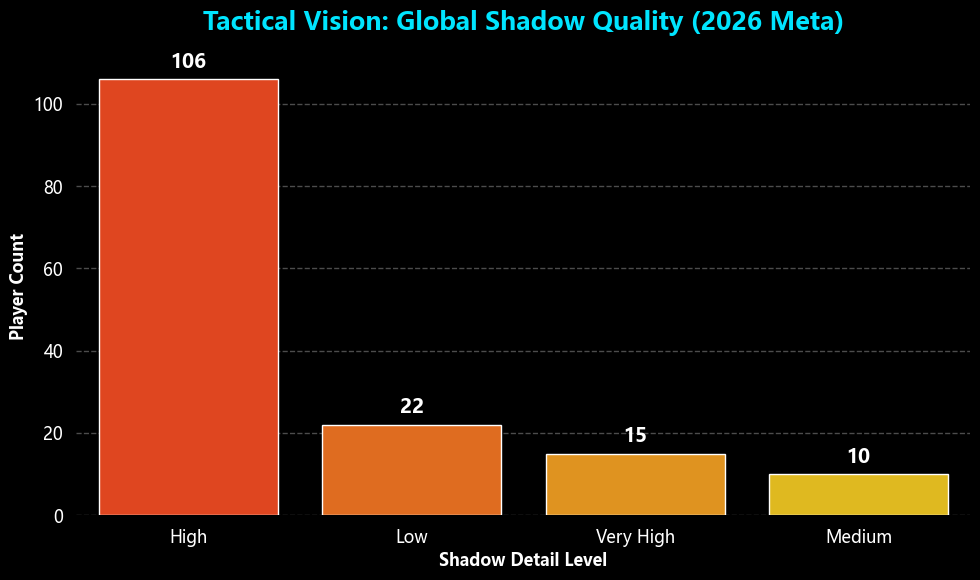

>>>[硬核解读] 如果 High 和 Very High 霸榜，说明职业哥宁可牺牲 FPS，也绝对要看清敌人的影子前摇！


In [38]:
# ==========================================
# 📊 补充图表 1：全局阴影质量 (战术视野的核心)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 确保暗黑风格与中文字体
plt.style.use('dark_background')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 提取阴影数据并计算数量
shadow_data = df_pro['Global Shadow Quality'].value_counts()

plt.figure(figsize=(10, 6))
# 使用亮橙色到霓虹粉的渐变，代表光影的照射
colors = sns.color_palette("autumn", len(shadow_data))

# 绘制柱状图
ax = sns.barplot(x=shadow_data.index, y=shadow_data.values, palette=colors, edgecolor='#ffffff')

# 在柱子顶部加上具体的数值标签
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=14, fontweight='bold', color='white', xytext=(0, 5), textcoords='offset points')

plt.title('Tactical Vision: Global Shadow Quality (2026 Meta)', fontsize=18, fontweight='bold', color='#00E5FF', pad=20)
plt.ylabel('Player Count', fontsize=12, fontweight='bold')
plt.xlabel('Shadow Detail Level', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 隐藏边框
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print(">>>[硬核解读] 如果 High 和 Very High 霸榜，说明职业哥宁可牺牲 FPS，也绝对要看清敌人的影子前摇！")

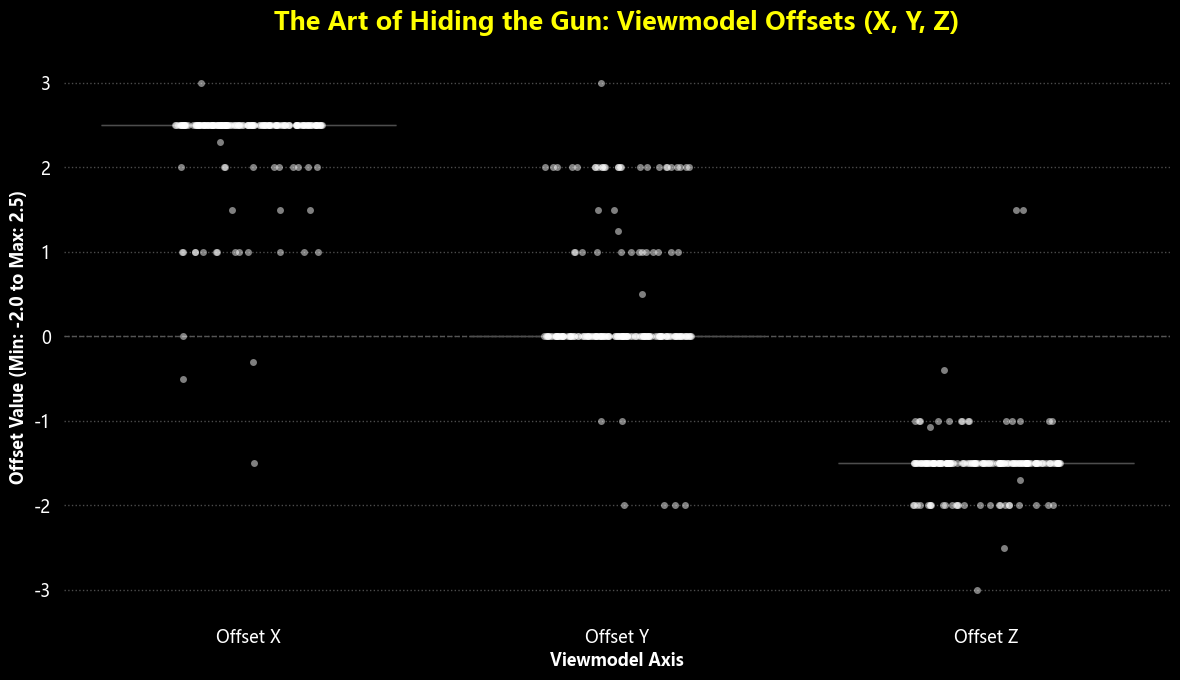

>>> [硬核解读] 注意看 Offset X (左右) 和 Offset Y (前后) 是否被顶到了极限值 (2.5 或 2.0)！这证明了大家都想把枪扔得离视野中心越远越好。


In [39]:
# ==========================================
# 📊 补充图表 2：持枪视角偏移分布 (X, Y, Z 轴的极致微调)
# ==========================================
import pandas as pd

plt.figure(figsize=(12, 7))

# 提取 XYZ 偏移量数据并融合成适合 Seaborn 画箱线图的格式
offset_cols = ['Offset X', 'Offset Y', 'Offset Z']
df_offsets = df_pro[offset_cols].melt(var_name='Axis', value_name='Offset Value')

# 定义 XYZ 的专属赛博配色: 冰蓝(X), 荧光绿(Y), 霓虹粉(Z)
xyz_colors =['#00E5FF', '#00FF00', '#FF00FF']

# 绘制带有数据点散布的箱线图 (Boxplot + Stripplot)
sns.boxplot(x='Axis', y='Offset Value', data=df_offsets, 
            palette=xyz_colors, boxprops=dict(alpha=0.6), showfliers=False)

# 叠加上面每一位选手的真实数值点 (加一点抖动 jitter 方便看清聚集情况)
sns.stripplot(x='Axis', y='Offset Value', data=df_offsets, 
              color='white', alpha=0.5, jitter=0.2, size=5)

plt.title('The Art of Hiding the Gun: Viewmodel Offsets (X, Y, Z)', fontsize=18, fontweight='bold', color='#FFFF00', pad=20)
plt.ylabel('Offset Value (Min: -2.0 to Max: 2.5)', fontsize=12, fontweight='bold')
plt.xlabel('Viewmodel Axis', fontsize=12, fontweight='bold')

# 添加基准辅助线 (0点)
plt.axhline(0, color='#555555', linestyle='--', linewidth=1)
plt.grid(axis='y', linestyle=':', alpha=0.3)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print(">>> [硬核解读] 注意看 Offset X (左右) 和 Offset Y (前后) 是否被顶到了极限值 (2.5 或 2.0)！这证明了大家都想把枪扔得离视野中心越远越好。")

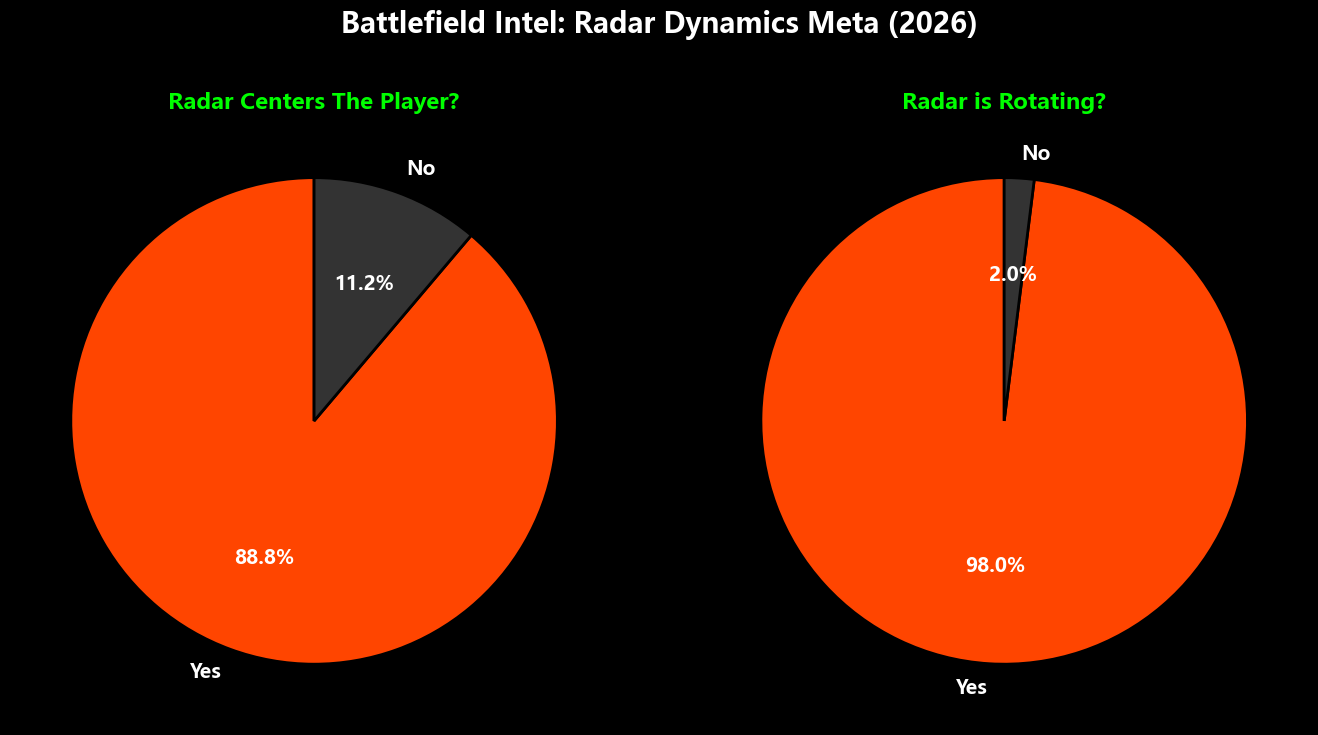

>>>[硬核解读] 真正的大局观玩家通常会关闭 'Centers The Player'，这样即使站在地图边缘，也能看清全图；而 'Rotating' 则取决于个人的空间感习惯！


In [40]:
# ==========================================
# 📊 补充图表 3：雷达动态习惯 (旋转与中心锁定)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 设定统一的饼图颜色: 亮橙色(Yes) vs 极暗灰(No)
pie_colors =['#FF4500', '#333333']
text_props = {'fontsize': 14, 'fontweight': 'bold', 'color': 'white'}
wedge_props = {'edgecolor': 'black', 'linewidth': 2}

# --- 图 1: Radar Centers The Player (雷达是否始终以自己为中心) ---
centers_data = df_pro['Radar Centers The Player'].value_counts()
# 确保饼图顺序 (Yes, No)
if 'Yes' in centers_data and 'No' in centers_data:
    centers_data = centers_data[['Yes', 'No']]

axes[0].pie(centers_data, labels=centers_data.index, autopct='%1.1f%%', startangle=90, 
            colors=pie_colors, textprops=text_props, wedgeprops=wedge_props)
axes[0].set_title('Radar Centers The Player?', fontsize=16, fontweight='bold', color='#00FF00')

# --- 图 2: Radar is Rotating (雷达是否随视角旋转) ---
rotating_data = df_pro['Radar is Rotating'].value_counts()
if 'Yes' in rotating_data and 'No' in rotating_data:
    rotating_data = rotating_data[['Yes', 'No']]

axes[1].pie(rotating_data, labels=rotating_data.index, autopct='%1.1f%%', startangle=90, 
            colors=pie_colors, textprops=text_props, wedgeprops=wedge_props)
axes[1].set_title('Radar is Rotating?', fontsize=16, fontweight='bold', color='#00FF00')

# 添加整个图的大标题
plt.suptitle('Battlefield Intel: Radar Dynamics Meta (2026)', fontsize=20, fontweight='bold', color='white', y=1.05)
plt.tight_layout()
plt.show()

print(">>>[硬核解读] 真正的大局观玩家通常会关闭 'Centers The Player'，这样即使站在地图边缘，也能看清全图；而 'Rotating' 则取决于个人的空间感习惯！")

In [42]:
import io

print("【1. 数据集基本信息 (Info)】")
buffer = io.StringIO()
df_pro.info(buf=buffer)
print(buffer.getvalue())

print("\n【2. 格式混乱的脏数据样本 (前 15 行)】")
# 🔧 这里去掉了 to_markdown()，改用原生的 to_string()，免安装直接出结果！
print(df_pro.head(15).to_string())

print("\n【3. 包含空值 (NaN) 最多的列】")
print(df_pro.isnull().sum()[df_pro.isnull().sum() > 0].to_string())

【1. 数据集基本信息 (Info)】
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 51 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Player                            184 non-null    object 
 1   Team                              184 non-null    object 
 2   DPI                               184 non-null    float64
 3   Sensitivity                       184 non-null    float64
 4   eDPI                              184 non-null    float64
 5   Zoom Sensitivity                  184 non-null    float64
 6   Hz                                184 non-null    float64
 7   Windows Sensitivity               184 non-null    float64
 8   Resolution                        184 non-null    object 
 9   Aspect Ratio                      184 non-null    object 
 10  Scaling Mode                      184 non-null    object 
 11  Refresh Rate                      183 non-null    f